### 논문 : Predicting and improving complex beer flavor through machine learning
- 논문의 250개의 맥주 데이터에 대해 231가지의 화학성분과 50가지의 관능평가 점수로 이뤄진 데이터에 대해서 데이터전처리까지 과정
1. 이후에 데이터 전처리 개선이 필요한 부분과
2. 생성모델로 개선할 수 있는 실험 전개

# 
### 목적 : 술 맛을 정확히 예측할 수 있는 모델을 만들고싶음.
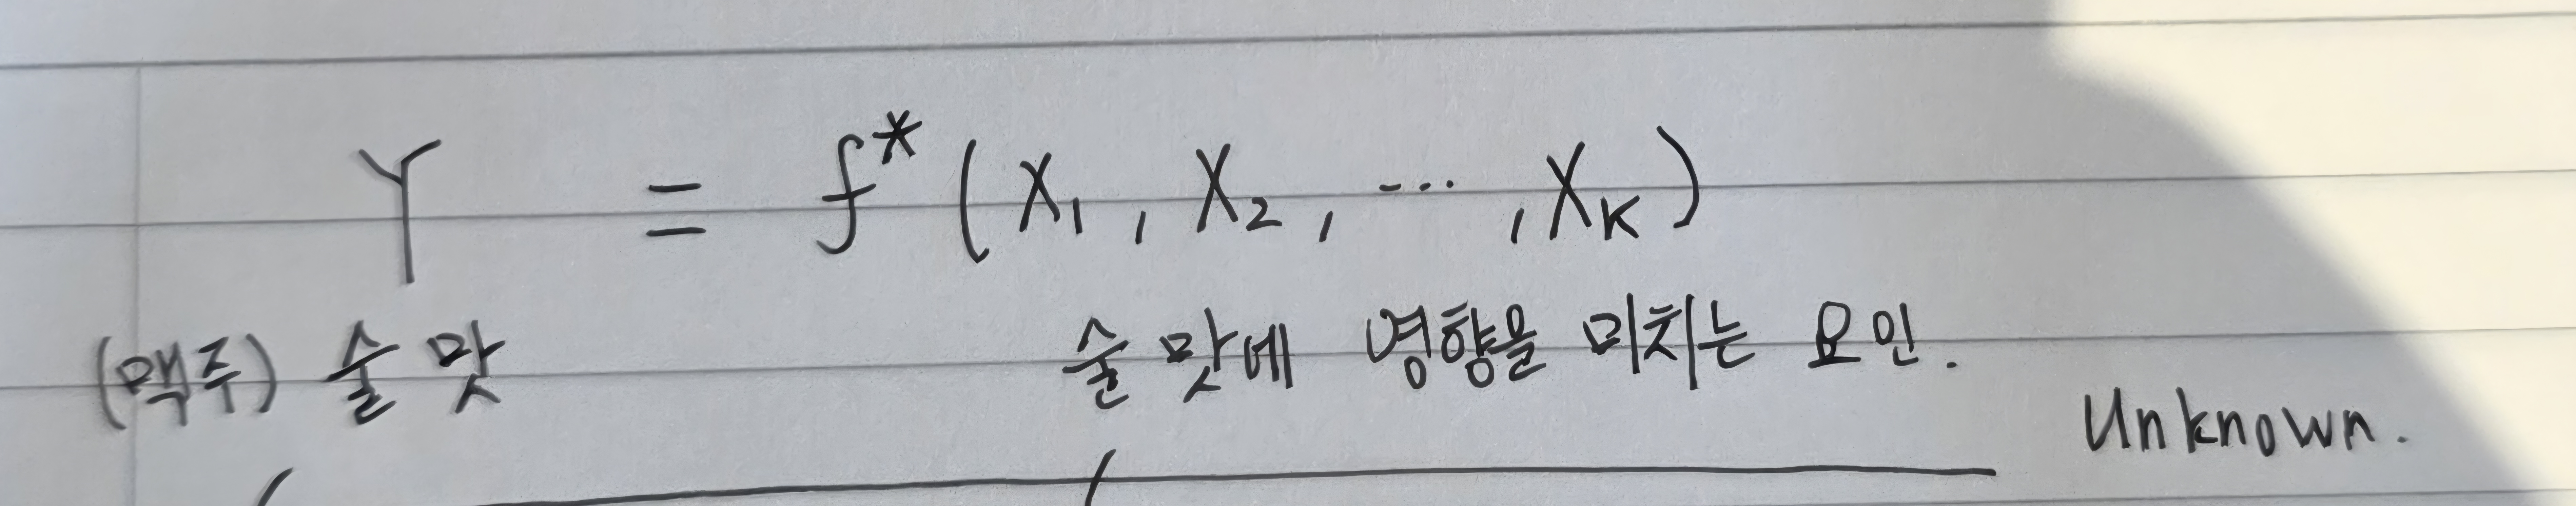
#### 1. Unknown 1. 술 맛(Y)을 어떻게 표현할 것인가?
- 술의 맛은 주관적
- 맛을 정량화하는 어려움
#### 2. Unknown 2. 술 맛에 영향을 미치는 요인을 어떻게 찾아낼 것인가?
- 술 맛에 영향을 미치는 요인은 Unknown.
- 술 맛에 영향을 미칠 것으로 짐작되는 요인들을 이때까지 알려진 과학적 근거 등을 고려하여 선택해야할 것임.
- 이때 시간, 비용 측면도 고려.
- 참인 함수($f^*$)와도 관련되어 있음.
#### 3. Unknown 3. 참인 함수를 어떻게 찾아낼 것인가?
- 관측 데이터를 기반으로 함수를 근사화하는 모델들을 고려.
# 

### 실제로 설계하여 얻은 데이터
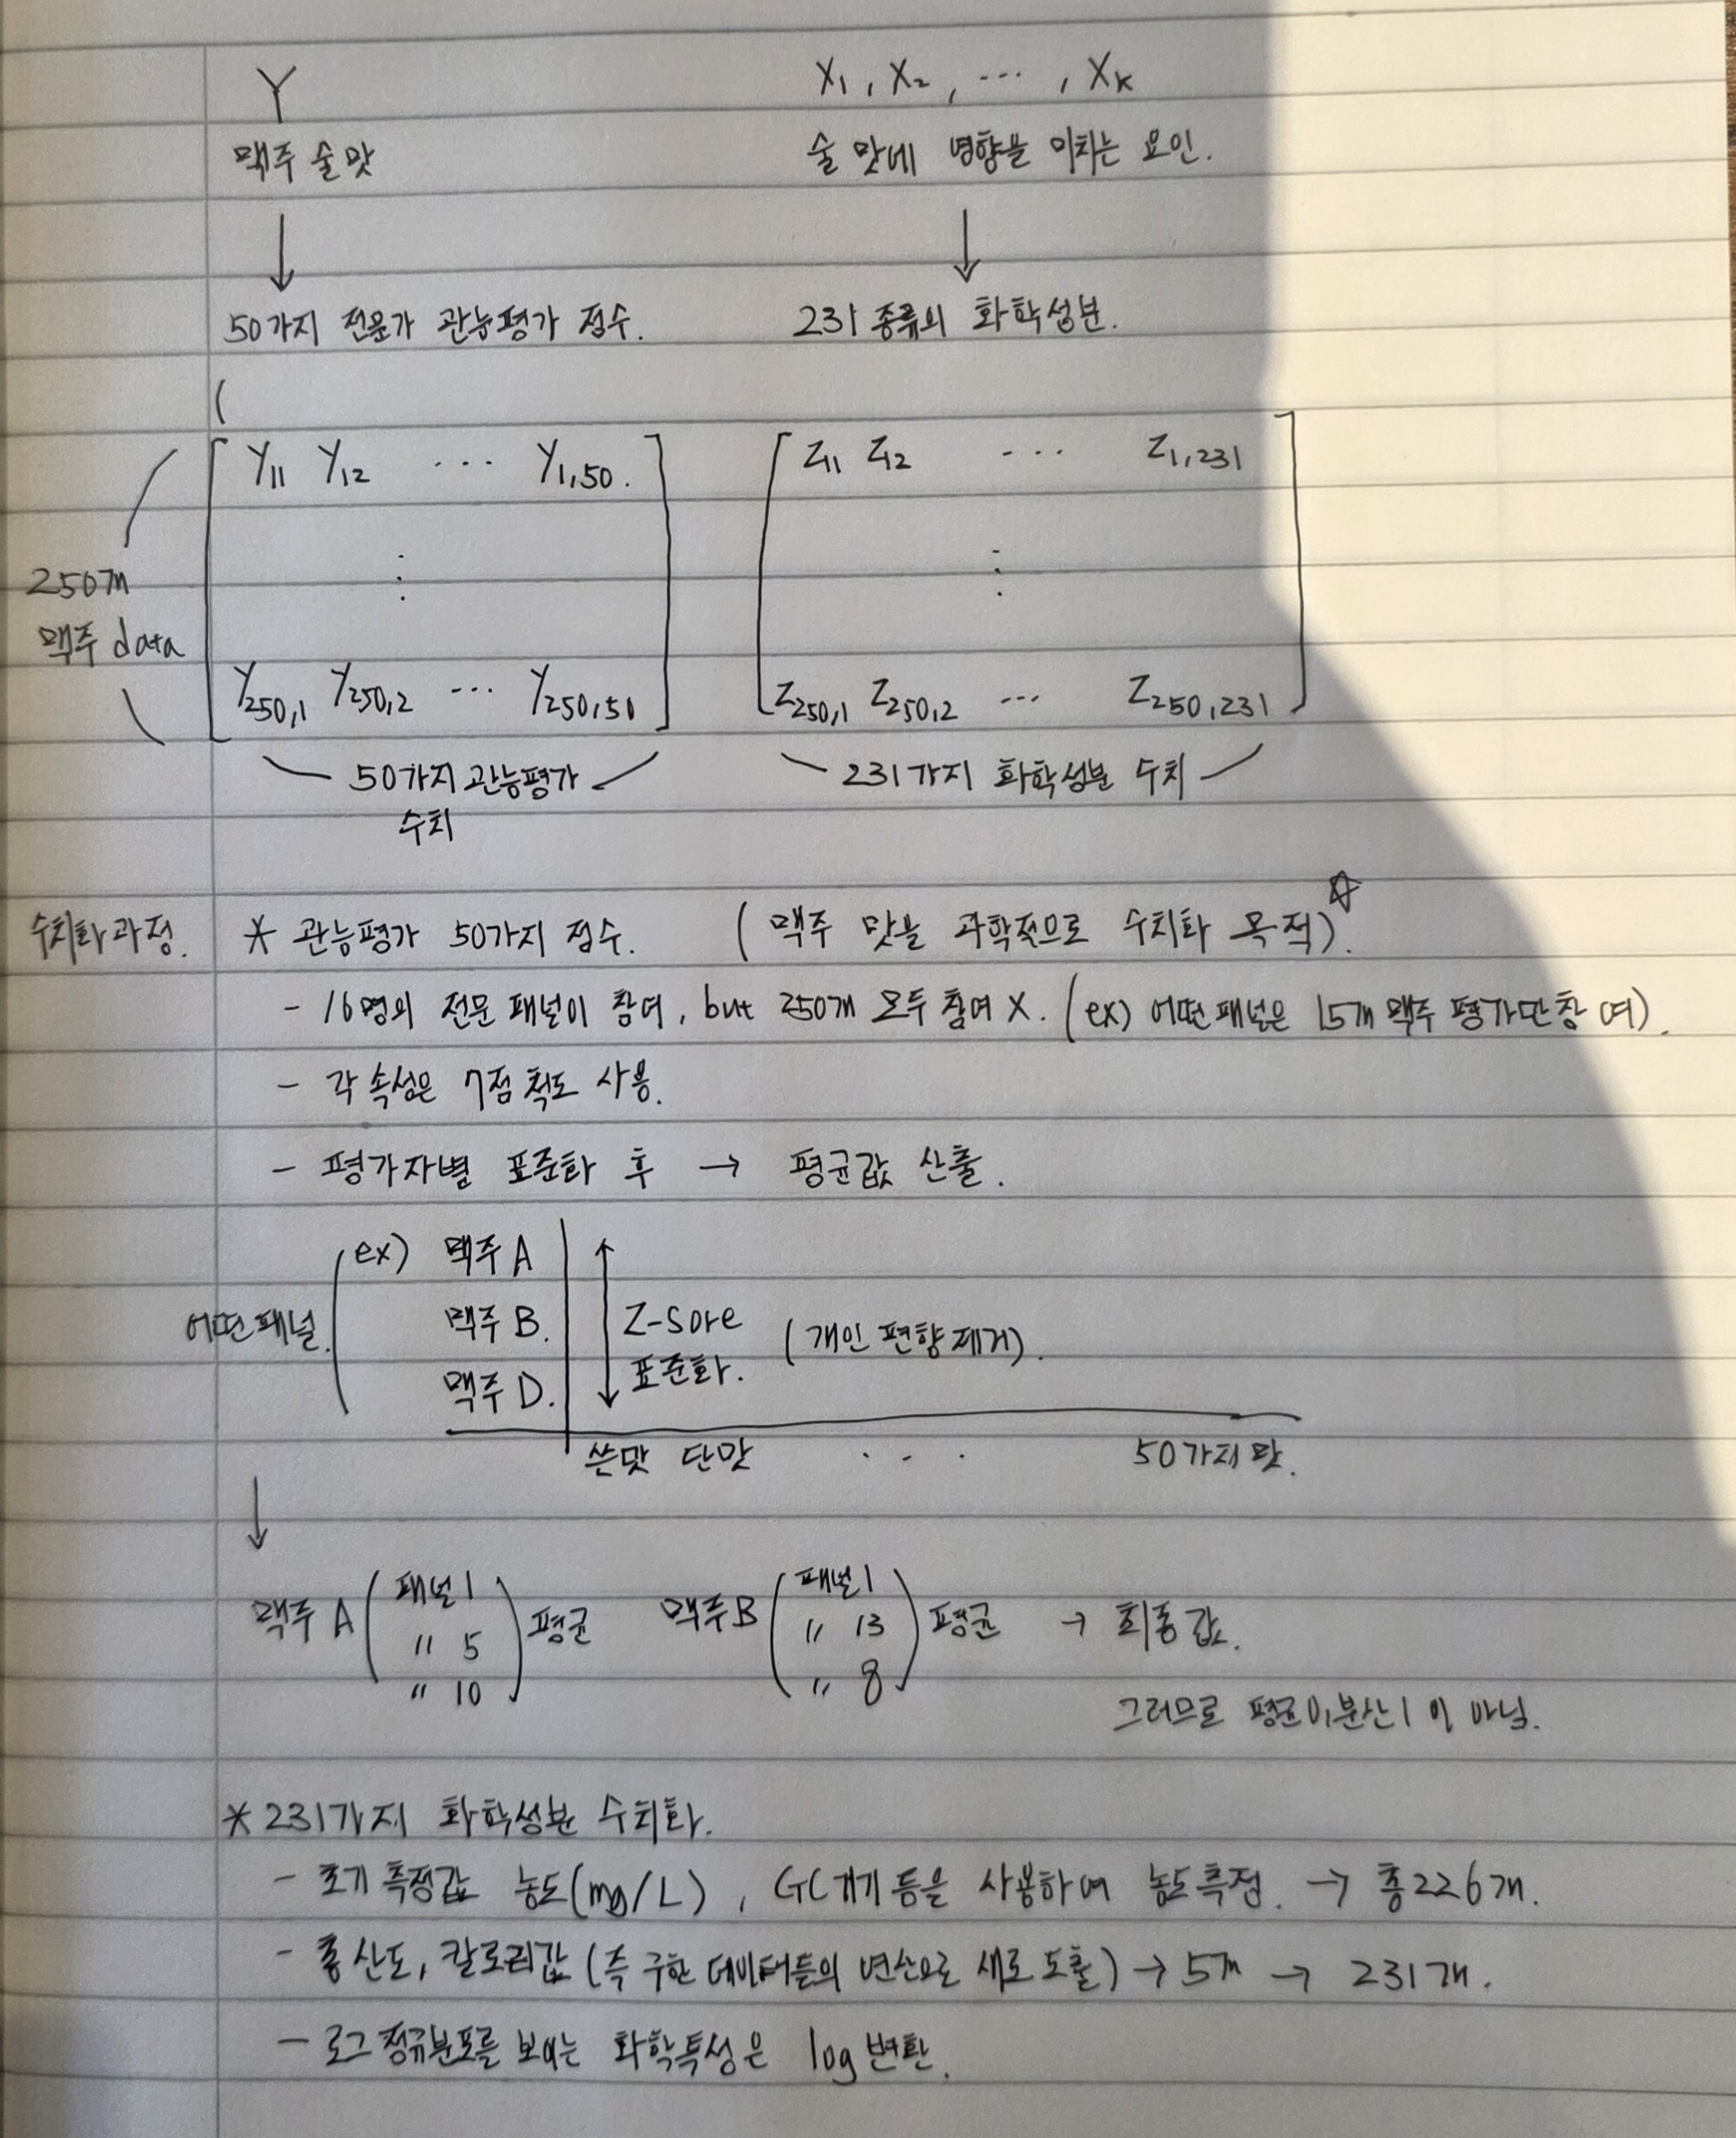

#### 1. 술 맛을 과학적으로 정량화하였다고 할 수 있는가?
- 여러 전문 패널(소믈리에 등) 참여
- 개인적 편향 제거
- 평균을 낸 것
#### 2. 술 맛에 영향을 미치는 요인을 잘 설계하였다고 할 수 있는가?
1. 화학적 측면 :
- 술에 대한 화학성분은 변하지 않음, 또한 블렌딩은 단순한 화학성분의 결합으로 나타남.
- 비용 측면 : 구하는 것이 부담될 수 있으나 구해놓으면 불변이므로 수용.

2. 수학적 측면 :
- 맥주 종류(개수)에 비해 화학성분 개수 관계 (250개 맥주에 231개 화학성분)
- 선형모델 관점에서 방정식 수보다 변수 수가 적으므로 최소제곱해를 고려해볼 수 있음.
- 하지만 열벡터들끼리의 일차종속이 존재하면 분산이 커질 수 있음. 즉 선형모델의 입력 데이터 성질로 일차종속 or 다중공선성이 존재하면 ill-condition이 되어 해의 분산이 매우 커질 우려가 있음.

In [1]:
import os
from platform import system
import pandas as pd
import numpy as np
from numpy.random import randint

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, MultiTaskLassoCV
from sklearn.cross_decomposition import PLSRegression

from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from xgboost import XGBRegressor

from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

import optuna

import pickle
import joblib
import warnings

# 모든 FutureWarning 메시지를 무시합니다.
warnings.simplefilter(action='ignore', category=FutureWarning)

#### Working directory

In [2]:
import os
import numpy as np

# 1. 이동하고 싶은 실제 경로를 변수에 담습니다. (앞에 r을 붙여줍니다)
target_path = r"C:\Users\Admin\Desktop\NutriHeal AI 연구 자료\BEER"

# 2. 해당 경로로 작업 위치를 변경합니다.
try:
    os.chdir(target_path)
    print(f"작업 경로가 성공적으로 변경되었습니다:\n{os.getcwd()}")
except FileNotFoundError:
    print(f"경로를 찾을 수 없습니다. 폴더가 실제로 존재하는지 확인해주세요:\n{target_path}")

# 3. 랜덤 시드 설정
np.random.seed(42)

작업 경로가 성공적으로 변경되었습니다:
C:\Users\Admin\Desktop\NutriHeal AI 연구 자료\BEER


In [3]:
from init_modeling import generate_X
from init_modeling import regressor_performance, pickle_model

Creating required folders

In [4]:
for path in ['models', 'Model_performance', 'Optimal_settings']:
    if not os.path.exists(path):
        os.makedirs(path)

#### Test train split
Comment/uncomment one of both sections to select the RateBeer or the Trained Panel sensory datasets.
Note that the RateBeer dataset is not available without prior written permission from RateBeer (ZX Ventures, USA).

- 소비자 리뷰 데이터 (RateBeer) 
- 전문가 패널 데이터 (Trained Panel) 

- 논문에서는 
1. Train / Test 7:3 비율로 나눔, 맥주의 세부스타일 기준으로 층화추출
2. Train의 정규화를 Test에도 적용 (평균0 분산1 정규화)
3. 결측치 평균값 대체
4. 이상치에 대한 작업은 따로 없음

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
# init_modeling.py가 같은 폴더에 있어야 합니다.
from init_modeling import generate_X 

# 1. 엑셀 파일에서 데이터 로드
# (파일 이름이 정확해야 하며, 같은 폴더에 위치해야 합니다)
excel_filename = 'Supplemental Files and Figure source files.xlsx'

# 시트 이름 지정 (엑셀 파일 내부의 시트명 확인 필요)
chem_dataset = pd.read_excel(excel_filename, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(excel_filename, sheet_name='Supplementary File S4').set_index('beer')

# 2. 데이터 병합 (Suffix 지정)
# 두 데이터셋에 모두 'beer_id'와 'tasting_category_fine'이 있어 충돌하므로 접미사를 붙입니다.
# _chem: 화학 데이터 유래, _panel: 패널 데이터 유래
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# 3. X (Features) 생성
x_name = 'chem_log'

# 중요: 'beer_id' 컬럼도 'beer_id_chem'으로 이름이 바뀌었으므로 이를 사용합니다.
# 또한 generate_X 함수 내부에서 'beer_id'라는 정확한 이름을 찾아 제거하려고 할 수 있으므로,
# .rename('beer_id')를 통해 원래 이름으로 복구해서 전달합니다.
beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']

X_input = pd.concat([beer_id_col, target_features], axis=1)
X = generate_X(X_input, impute=True)

# 4. Y (Target) 생성
y_name = 'expertpanel'
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']

# 5. Stratify를 위한 클래스 정보 가져오기
# 중요: 'tasting_category_fine' 컬럼도 'tasting_category_fine_chem'으로 바뀌었습니다.
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# 6. Train/Test 분할
# 샘플 수가 적은 클래스로 인한 에러 방지를 위한 예외처리 추가
try:
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, 
        test_size=0.30,
        random_state=0, 
        shuffle=True, 
        stratify=y_class
    )
except ValueError:
    print("Warning: Stratified split failed (too few samples in some classes). Using random split.")
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, 
        test_size=0.30,
        random_state=0, 
        shuffle=True
    )

print("데이터 처리 완료")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

데이터 처리 완료
X_train shape: (175, 231)
Y_train shape: (175, 50)


#### Scaling the data
This is necessary for the Neural Network and Linear Models. Out of consistency, we do it for the whole dataset.

In [6]:
scaler_X = StandardScaler().fit(X_train)
# scaler_Y = StandardScaler().fit(Y_train)

X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)
# Y_train = scaler_Y.transform(Y_train)
# Y_test = scaler_Y.transform(Y_test)

In [7]:
import pandas as pd
import numpy as np

# 1. 모든 행과 열을 생략 없이 출력하도록 옵션 설정
pd.set_option('display.max_rows', None)      # 행 개수 제한 해제 (모든 변수 출력)
pd.set_option('display.max_columns', None)   # 열 개수 제한 해제
pd.set_option('display.width', 1000)         # 가로 폭 늘리기 (줄바꿈 방지)
pd.set_option('display.float_format', '{:.4f}'.format) # 소수점 4자리까지 표시

# 2. 스케일링된 X 데이터(numpy array)를 DataFrame으로 변환 (컬럼명 복구)
# (X 변수는 split 전에 정의되어 있으므로 columns 정보를 가지고 있습니다)
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Y 데이터는 DataFrame 형태 그대로 사용
# (혹시 numpy array라면 pd.DataFrame(Y_train, columns=Y.columns) 로 변환 필요)
Y_train_df = Y_train
Y_test_df = Y_test

# 3. 통계량 계산 및 출력 함수
def print_full_stats(df, name):
    print(f"\n" + "="*80)
    print(f"   [{name}] 전체 통계량 (Total Features: {df.shape[1]})")
    print("="*80)
    
    # describe()로 통계량 계산 후 전치(.T)하여 변수를 행으로 표시
    stats = df.describe().T[['mean', 'std', 'min', 'max']]
    print(stats)
    
    return stats

# 4. 실행 (모든 변수 출력)
print(">>> 모든 변수에 대한 통계량 출력을 시작합니다...")

# X (입력 변수 231개)
stats_x_train = print_full_stats(X_train_df, "X Train (Scaled)")
stats_x_test = print_full_stats(X_test_df, "X Test (Scaled)")

# Y (타겟 변수 50개)
stats_y_train = print_full_stats(Y_train_df, "Y Train (Original)")
stats_y_test = print_full_stats(Y_test_df, "Y Test (Original)")

# (참고) 출력이 너무 길어 콘솔에서 잘릴 경우 파일로 저장해서 보는 것을 추천합니다.
# stats_x_train.to_csv("X_train_full_stats.csv")
# stats_y_train.to_csv("Y_train_full_stats.csv")

>>> 모든 변수에 대한 통계량 출력을 시작합니다...

   [X Train (Scaled)] 전체 통계량 (Total Features: 231)
                                           mean    std      min     max
acetaldehyde                             0.0000 1.0029  -6.0181  1.7213
CS2                                     -0.0000 1.0029  -0.4221  3.3059
DES                                      0.0000 1.0029  -2.3871  1.5718
DMS                                     -0.0000 1.0029  -3.7494  3.6621
ethyl_2.methyl_butyrate                 -0.0000 1.0029  -1.2409  2.9341
ethyl_acetate                            0.0000 1.0029  -5.9393  2.1607
ethyl_decanoate                         -0.0000 1.0029  -3.8311  1.6264
ethyl_hexanoate                         -0.0000 1.0029  -5.5570  1.8024
ethyl_isovalerate                        0.0000 1.0029  -1.4239  1.5754
ethyl_octanoate                          0.0000 1.0029  -4.2152  1.5597
ethyl_propionate                        -0.0000 1.0029  -2.9063  2.6585
H2S                                     -0.0000 1.002

                                           mean      std      min       max
acetaldehyde                             0.1278   0.7340  -1.6336    1.6650
CS2                                      0.0341   0.9970  -0.4221    3.0601
DES                                     -0.0805   0.9987  -2.3871    1.5793
DMS                                     -0.0372   0.7950  -1.7067    2.2017
ethyl_2.methyl_butyrate                 -0.1231   0.9759  -1.2409    2.0239
ethyl_acetate                           -0.0262   0.9785  -4.8494    1.2741
ethyl_decanoate                         -0.0085   0.9047  -2.0810    1.6604
ethyl_hexanoate                         -0.1390   1.0300  -4.4914    1.6306
ethyl_isovalerate                       -0.1395   1.0516  -1.4239    1.6210
ethyl_octanoate                         -0.0620   0.9105  -3.8443    1.8080
ethyl_propionate                        -0.0131   0.9809  -2.9063    2.0669
H2S                                      0.0875   0.8043  -4.0526    1.5055
isoamyl_alco


>>> Processing Visualization for: Input X (Features)
  - Running PCA...
  - Running t-SNE...
  - Running UMAP...


C:\Users\Admin\anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  - Running Autoencoder...


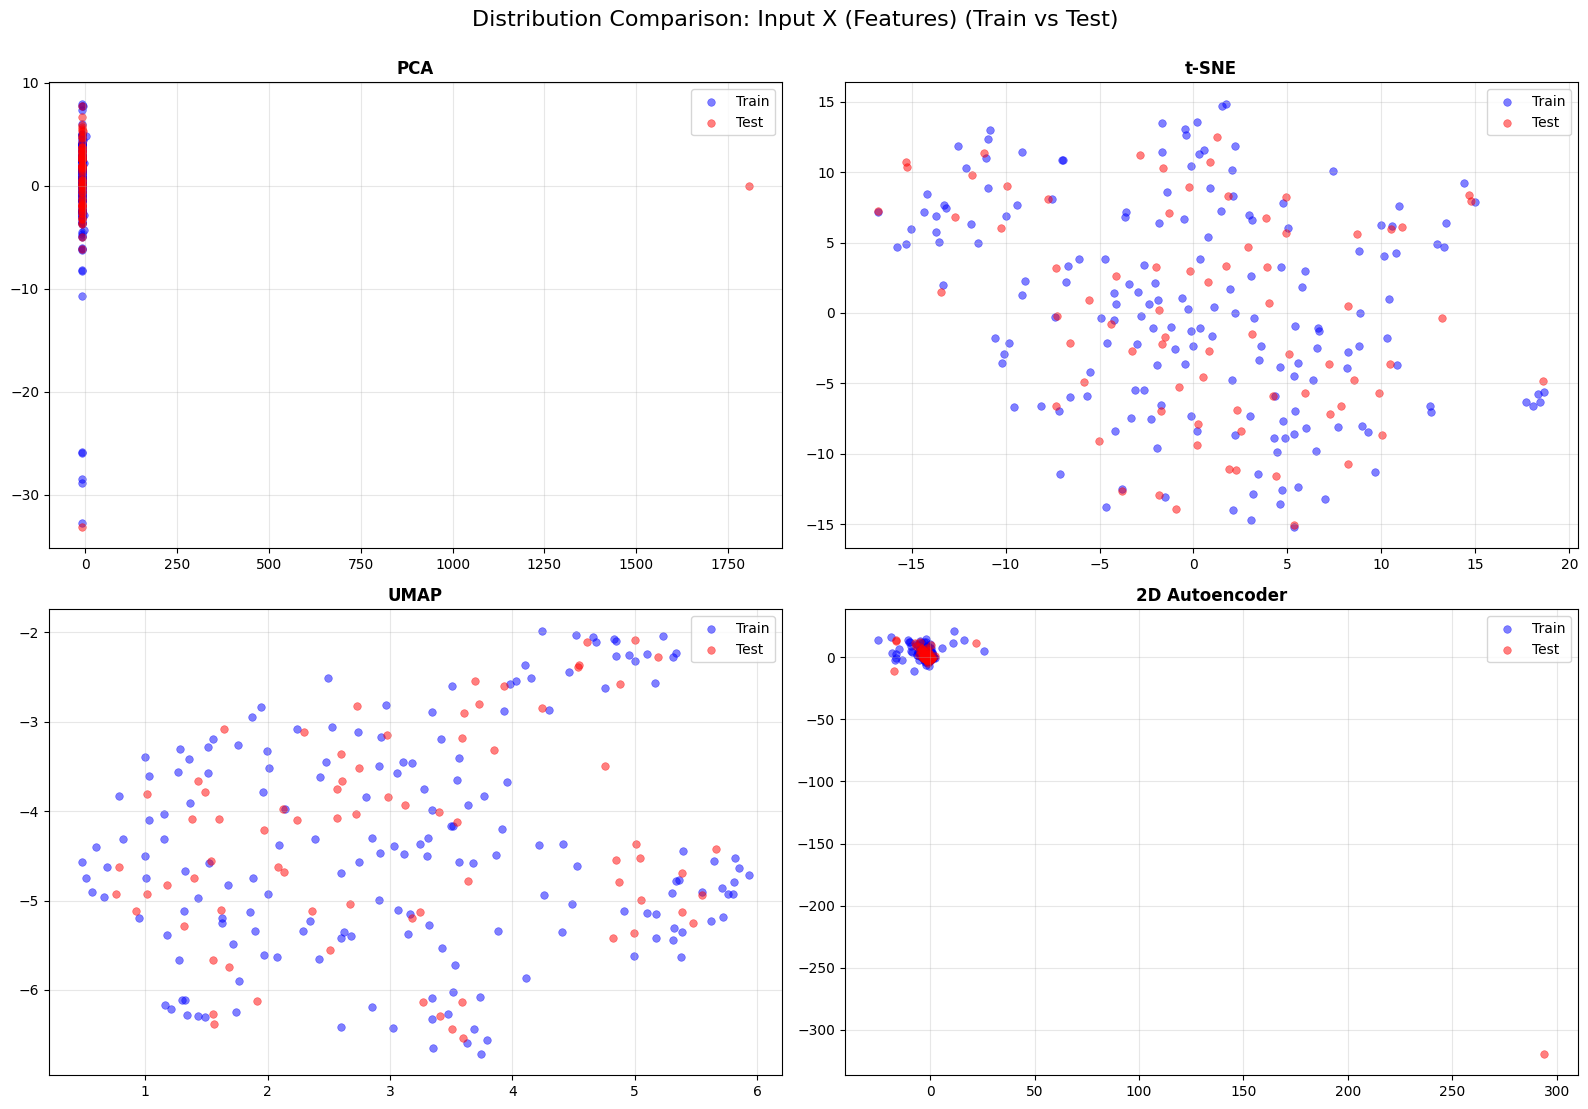


>>> Processing Visualization for: Target Y (Sensory Scores)
  - Running PCA...
  - Running t-SNE...
  - Running UMAP...


C:\Users\Admin\anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  - Running Autoencoder...


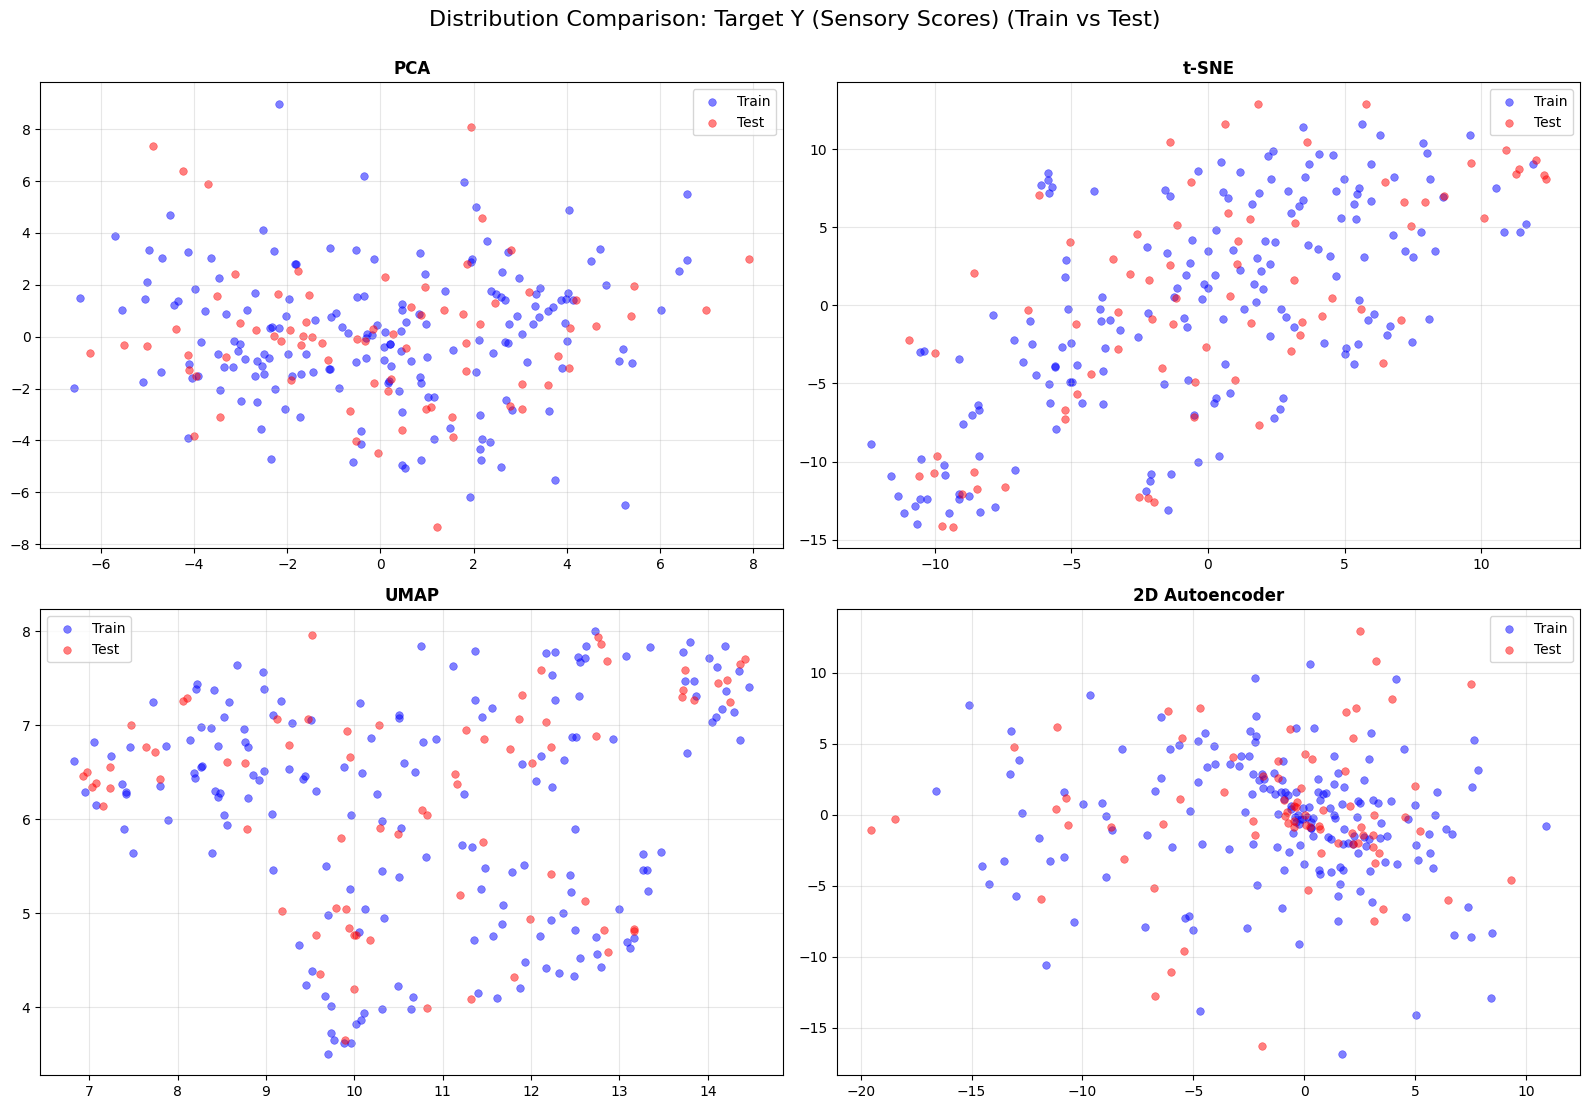

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# UMAP은 별도 설치가 필요할 수 있으므로 예외처리
try:
    import umap
except ImportError:
    print("![Warning] 'umap-learn' library is not installed. Skipping UMAP.")
    # pip install umap-learn

# ==========================================
# [0] 데이터 준비 (Scaling for Visualization)
# ==========================================
# X는 이미 Scaled 상태 (X_train, X_test는 numpy array)
# Y는 Original 상태이므로 시각화를 위해 스케일링 수행
scaler_y_vis = StandardScaler()
Y_train_scaled = scaler_y_vis.fit_transform(Y_train)
Y_test_scaled = scaler_y_vis.transform(Y_test)

# ==========================================
# [1] 2D Autoencoder Class Definition
# ==========================================
class Autoencoder2D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Encoder: Input -> ... -> 2D
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Latent Space (2D)
        )
        # Decoder: 2D -> ... -> Output
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

def train_get_latent_ae(data_train, data_test, epochs=100):
    # Combine for global view (or train on Train, project Test)
    # 여기서는 분포 비교를 위해 Combined 데이터로 학습하여 공통 Latent Space 형성
    combined = np.concatenate([data_train, data_test], axis=0)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    tensor_dat = torch.FloatTensor(combined).to(device)
    loader = DataLoader(TensorDataset(tensor_dat), batch_size=64, shuffle=True)
    
    model = Autoencoder2D(combined.shape[1]).to(device)
    opt = optim.Adam(model.parameters(), lr=0.005)
    crit = nn.MSELoss()
    
    # Train
    model.train()
    for _ in range(epochs):
        for (x,) in loader:
            recon, z = model(x)
            loss = crit(recon, x)
            opt.zero_grad(); loss.backward(); opt.step()
            
    # Extract Latent (2D)
    model.eval()
    with torch.no_grad():
        _, z_all = model(tensor_dat)
        latent_2d = z_all.cpu().numpy()
        
    # Split back
    n_train = len(data_train)
    return latent_2d[:n_train], latent_2d[n_train:]

# ==========================================
# [2] 시각화 함수 정의
# ==========================================
def plot_distributions(ax, z_train, z_test, title):
    # Train
    sns.scatterplot(x=z_train[:, 0], y=z_train[:, 1], ax=ax, 
                    color='blue', alpha=0.5, label='Train', s=30, edgecolor=None)
    # Test
    sns.scatterplot(x=z_test[:, 0], y=z_test[:, 1], ax=ax, 
                    color='red', alpha=0.5, label='Test', s=30, edgecolor=None)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

def compare_distributions(data_name, train_data, test_data):
    print(f"\n>>> Processing Visualization for: {data_name}")
    
    # 1. Prepare Data
    combined = np.concatenate([train_data, test_data], axis=0)
    n_tr = len(train_data)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.suptitle(f"Distribution Comparison: {data_name} (Train vs Test)", fontsize=16, y=0.95)
    
    # --- (A) PCA ---
    print("  - Running PCA...")
    pca = PCA(n_components=2)
    res_pca = pca.fit_transform(combined)
    plot_distributions(axes[0,0], res_pca[:n_tr], res_pca[n_tr:], "PCA")
    
    # --- (B) t-SNE ---
    print("  - Running t-SNE...")
    # t-SNE는 transform이 없으므로 전체 데이터를 한 번에 embedding 해야 함
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
    res_tsne = tsne.fit_transform(combined)
    plot_distributions(axes[0,1], res_tsne[:n_tr], res_tsne[n_tr:], "t-SNE")
    
    # --- (C) UMAP ---
    print("  - Running UMAP...")
    try:
        import umap
        reducer = umap.UMAP(random_state=42)
        res_umap = reducer.fit_transform(combined)
        plot_distributions(axes[1,0], res_umap[:n_tr], res_umap[n_tr:], "UMAP")
    except:
        axes[1,0].text(0.5, 0.5, "UMAP not installed", ha='center')
        axes[1,0].set_title("UMAP (Skipped)")

    # --- (D) Autoencoder ---
    print("  - Running Autoencoder...")
    z_ae_tr, z_ae_te = train_get_latent_ae(train_data, test_data, epochs=200)
    plot_distributions(axes[1,1], z_ae_tr, z_ae_te, "2D Autoencoder")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ==========================================
# [3] 실행 (X와 Y 각각 시각화)
# ==========================================

# 1. X Distribution (Input Features)
# X_train, X_test는 이미 Scaled 상태
compare_distributions("Input X (Features)", X_train, X_test)

# 2. Y Distribution (Target Labels)
# Scaling된 Y 데이터 사용
compare_distributions("Target Y (Sensory Scores)", Y_train_scaled, Y_test_scaled)

X2.methyltetrahydrofuran.3.one 변수가 이상치가 있어서 이를 제외하고 다시 시각화

>>> Removing Outlier Feature: 'X2.methyltetrahydrofuran.3.one' (Index: 47)
  - Original Shape: (175, 231)
  - New Shape     : (175, 230)

>>> Processing Visualizations (PCA, t-SNE, UMAP, Autoencoder)...
  - Running PCA...
  - Running t-SNE...
  - Running UMAP...


C:\Users\Admin\anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  - Running Autoencoder...


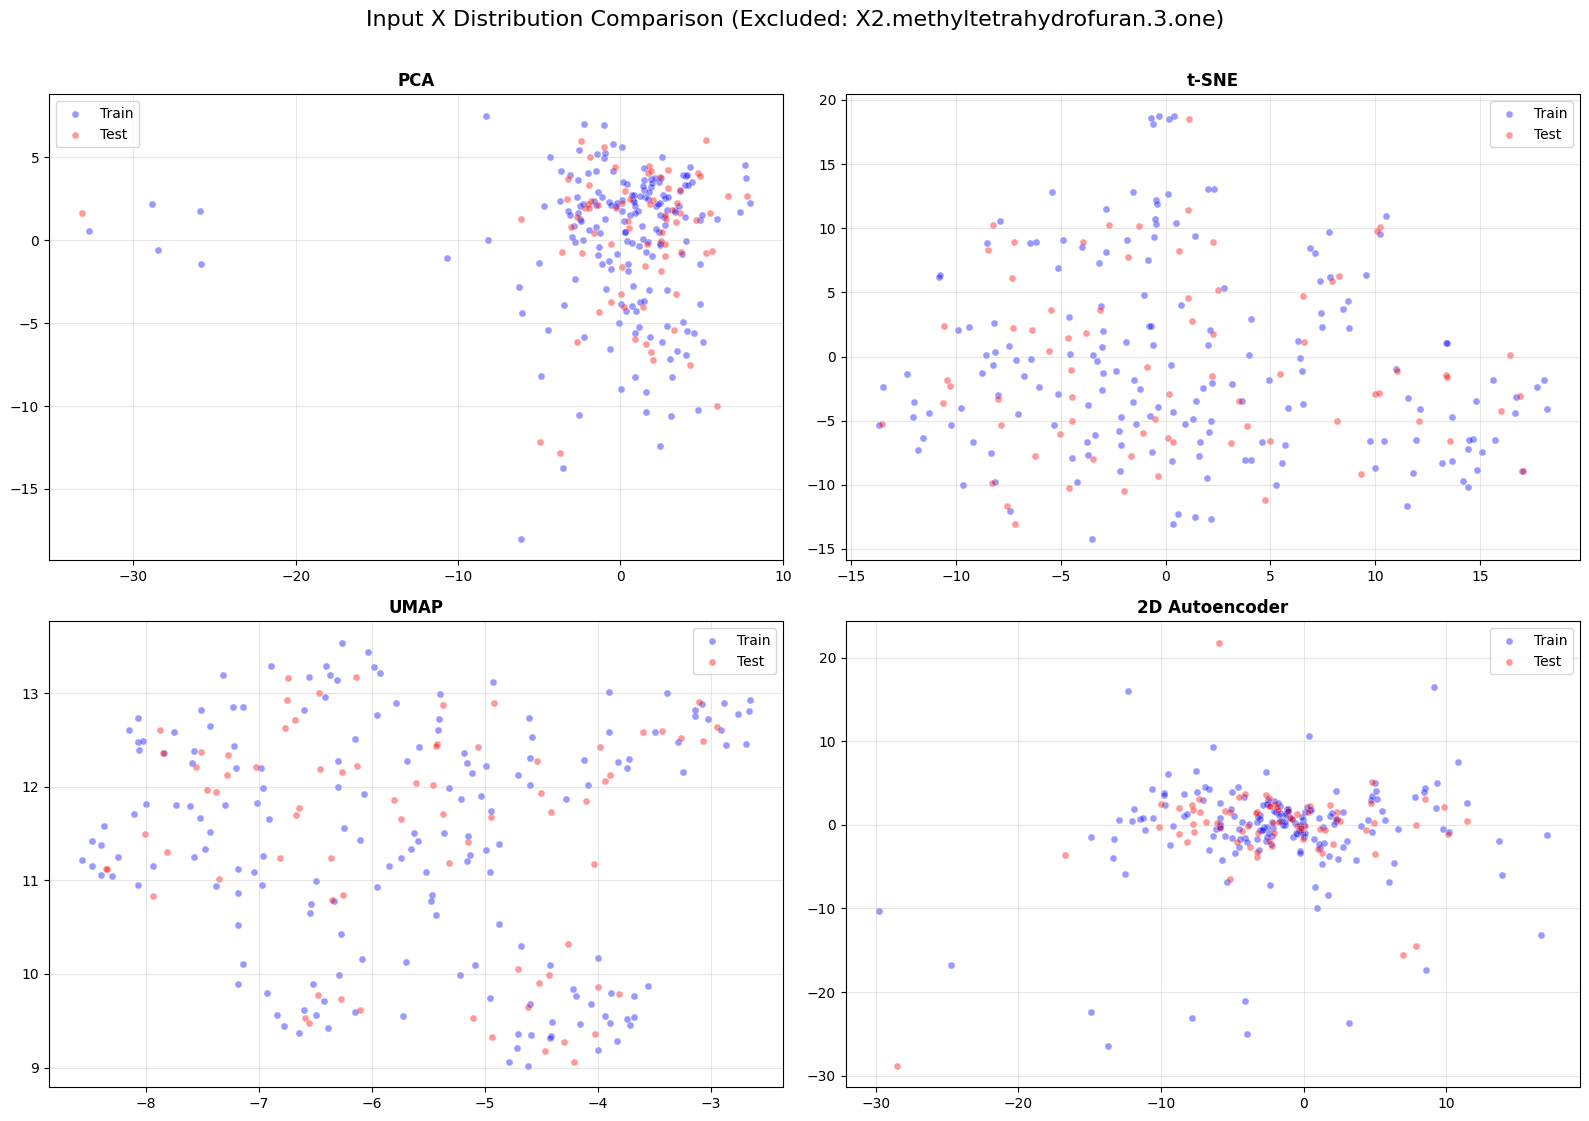

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# UMAP 라이브러리 확인
try:
    import umap
except ImportError:
    pass # UMAP이 없으면 아래에서 예외 처리됨

# ==========================================
# [Step 1] 특정 변수 제거 (X2.methyltetrahydrofuran.3.one)
# ==========================================
col_to_remove = 'X2.methyltetrahydrofuran.3.one'

# X.columns는 전처리 단계에서 정의된 데이터프레임의 컬럼명입니다.
if col_to_remove in X.columns:
    col_idx = X.columns.get_loc(col_to_remove)
    print(f">>> Removing Outlier Feature: '{col_to_remove}' (Index: {col_idx})")
    
    # Numpy 배열에서 해당 열(Column) 삭제
    # X_train, X_test는 이미 Scaled된 상태의 Numpy Array입니다.
    X_train_filtered = np.delete(X_train, col_idx, axis=1)
    X_test_filtered = np.delete(X_test, col_idx, axis=1)
    
    print(f"  - Original Shape: {X_train.shape}")
    print(f"  - New Shape     : {X_train_filtered.shape}")
else:
    print(f"![Warning] Column '{col_to_remove}' not found in columns. Using original data.")
    X_train_filtered = X_train
    X_test_filtered = X_test

# ==========================================
# [Step 2] 2D Autoencoder 모델 정의
# ==========================================
class Autoencoder2D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2)  # 2D Latent Space
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def train_get_latent(data_tr, data_te, epochs=100):
    combined = np.concatenate([data_tr, data_te], axis=0)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tensor_dat = torch.FloatTensor(combined).to(device)
    loader = DataLoader(TensorDataset(tensor_dat), batch_size=64, shuffle=True)
    
    model = Autoencoder2D(combined.shape[1]).to(device)
    opt = optim.Adam(model.parameters(), lr=0.005)
    crit = nn.MSELoss()
    
    # Train
    model.train()
    for _ in range(epochs):
        for (x,) in loader:
            recon, z = model(x)
            loss = crit(recon, x)
            opt.zero_grad(); loss.backward(); opt.step()
            
    # Inference
    model.eval()
    with torch.no_grad():
        _, z_all = model(tensor_dat)
        latent = z_all.cpu().numpy()
        
    return latent[:len(data_tr)], latent[len(data_tr):]

# ==========================================
# [Step 3] 시각화 함수
# ==========================================
def plot_dist(ax, z_tr, z_te, title):
    sns.scatterplot(x=z_tr[:,0], y=z_tr[:,1], ax=ax, color='blue', alpha=0.4, label='Train', s=25)
    sns.scatterplot(x=z_te[:,0], y=z_te[:,1], ax=ax, color='red', alpha=0.4, label='Test', s=25)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ==========================================
# [Step 4] 4가지 방식 비교 시각화 실행
# ==========================================
print("\n>>> Processing Visualizations (PCA, t-SNE, UMAP, Autoencoder)...")

# 데이터 준비
X_comb = np.concatenate([X_train_filtered, X_test_filtered], axis=0)
n_tr = len(X_train_filtered)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.suptitle(f"Input X Distribution Comparison (Excluded: {col_to_remove})", fontsize=16, y=0.96)

# 1. PCA
print("  - Running PCA...")
pca = PCA(n_components=2)
res_pca = pca.fit_transform(X_comb)
plot_dist(axes[0,0], res_pca[:n_tr], res_pca[n_tr:], "PCA")

# 2. t-SNE
print("  - Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
res_tsne = tsne.fit_transform(X_comb)
plot_dist(axes[0,1], res_tsne[:n_tr], res_tsne[n_tr:], "t-SNE")

# 3. UMAP
print("  - Running UMAP...")
try:
    import umap
    reducer = umap.UMAP(random_state=42)
    res_umap = reducer.fit_transform(X_comb)
    plot_dist(axes[1,0], res_umap[:n_tr], res_umap[n_tr:], "UMAP")
except:
    axes[1,0].text(0.5, 0.5, "UMAP not installed", ha='center')
    axes[1,0].set_title("UMAP (Skipped)")

# 4. Autoencoder
print("  - Running Autoencoder...")
z_ae_tr, z_ae_te = train_get_latent(X_train_filtered, X_test_filtered, epochs=150)
plot_dist(axes[1,1], z_ae_tr, z_ae_te, "2D Autoencoder")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 
## 생성모델 초점

#### 1. Xgboost가 R^2가 0.22 정도로 가장 좋게 나왔다고 논문에 언급되어있으므로 이 모델 코드를 예측 모델로 잡고
#### 2. 생성모델로 생성된 데이터와 기본 데이터 비교

밑에는 이상치 데이터가 존재한다고 생각되는 X2.methyltetrahydrofuran.3.one 변수까지 포함한(즉 논문에서 사용한) 데이터들을 그대로 사용한 결과

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import os

# [설정] 디바이스 및 시드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
torch.manual_seed(42)

print(f">>> [Setup] Device: {DEVICE}")

# ==========================================
# [Step 1] Diffusion 학습을 위한 데이터 준비
# ==========================================
# X_train, X_test는 이미 Scaled 상태라고 가정
# Y_train, Y_test는 Original DataFrame 상태

# Diffusion 학습을 위해 Y도 임시로 스케일링 (분포 매칭을 위해 필수)
scaler_Y_diff = StandardScaler()
Y_train_scaled = scaler_Y_diff.fit_transform(Y_train) 

# X와 Y 결합 (Conditions)
real_data = np.concatenate([X_train, Y_train_scaled], axis=1)
dim_x = X_train.shape[1]
dim_y = Y_train_scaled.shape[1]
full_dim = dim_x + dim_y

print(f">>> [Data Prep] Input Dim: {full_dim} (X:{dim_x} + Y:{dim_y})")

train_tensor = torch.FloatTensor(real_data).to(DEVICE)
dataloader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

# ==========================================
# [Step 2] Diffusion Model 정의 및 학습
# ==========================================
class DiffusionModel(nn.Module):
    def __init__(self, dim, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(dim + hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x, t):
        t = t.view(-1, 1).float()
        t_emb = self.time_mlp(t)
        x_in = torch.cat([x, t_emb], dim=1)
        return self.net(x_in)

# Diffusion Hyperparameters
TIMESTEPS = 1000
EPOCHS = 5000  # 학습 횟수
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(DEVICE)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

model = DiffusionModel(full_dim).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"\n>>> [Diffusion] Training Start ({EPOCHS} epochs)...")
model.train()
for ep in range(EPOCHS):
    total_loss = 0
    for (x0,) in dataloader:
        t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=DEVICE)
        noise = torch.randn_like(x0)
        
        # Forward Process
        sqrt_alpha_bar = torch.sqrt(alphas_cumprod[t]).view(-1, 1)
        sqrt_one_minus_alpha_bar = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1)
        x_t = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise
        
        # Predict Noise
        pred_noise = model(x_t, t.float() / TIMESTEPS)
        loss = nn.MSELoss()(pred_noise, noise)
        
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        
    if (ep+1) % 500 == 0:
        print(f"  - Ep {ep+1:4d} | Loss: {total_loss/len(dataloader):.5f}")

# ==========================================
# [Step 3] 데이터 생성 및 필터링 (Manifold Filtering)
# ==========================================
print("\n>>> [Generation] Sampling & Manifold Filtering...")

model.eval()
# 원본 데이터의 3배수 생성 후 필터링
N_GEN = len(X_train) * 3
x_gen = torch.randn(N_GEN, full_dim).to(DEVICE)

with torch.no_grad():
    for i in reversed(range(TIMESTEPS)):
        t = torch.full((N_GEN,), i, device=DEVICE, dtype=torch.long)
        pred_noise = model(x_gen, t.float() / TIMESTEPS)
        
        alpha = alphas[i]
        alpha_cumprod_t = alphas_cumprod[i]
        beta = betas[i]
        
        if i > 0: noise = torch.randn_like(x_gen)
        else: noise = 0
        
        # Reverse Step
        x_gen = (1 / torch.sqrt(alpha)) * (x_gen - (beta / torch.sqrt(1 - alpha_cumprod_t)) * pred_noise) + torch.sqrt(beta) * noise

gen_data_np = x_gen.cpu().numpy()

# --- Manifold Filtering ---
# 생성된 데이터가 실제 데이터 분포(Manifold) 근처에 있는지 확인
nbrs = NearestNeighbors(n_neighbors=1).fit(real_data)
distances, _ = nbrs.kneighbors(gen_data_np)

# 기준: 평균 거리보다 가까운 데이터만 남김 (너무 동떨어진 데이터 제거)
threshold = distances.mean()
valid_indices = np.where(distances < threshold)[0]
filtered_data = gen_data_np[valid_indices]

print(f"  - Generated: {N_GEN} -> Filtered: {len(filtered_data)} (Threshold: {threshold:.4f})")

# 데이터 분리 및 Y 역변환
X_syn = filtered_data[:, :dim_x]       # 이미 Scaled 상태
Y_syn_scaled = filtered_data[:, dim_x:] 
Y_syn = scaler_Y_diff.inverse_transform(Y_syn_scaled) # Original Scale로 복원

# ==========================================
# [Step 4] XGBoost 비교 실험 (Baseline vs Augmented)
# ==========================================
print("\n" + "="*60)
print(">>> [Comparison] Running XGBoost GridSearch Experiments")
print("="*60)

# 사용자 정의 XGBoost 실험 함수
def run_xgboost_experiment(exp_name, X_tr, Y_tr, X_te, Y_te):
    print(f"\n[{exp_name}] Training Start...")
    print(f"  - Train Size: {X_tr.shape[0]}")
    
    # [사용자 요청 옵션 적용]
    # eta는 sklearn wrapper에서 learning_rate로 매핑됩니다.
    # MultiOutputRegressor를 사용하여 다중 타겟 예측
    
    param_grid = [{
        'estimator__learning_rate': [0.01, 0.05, 0.1],  # eta와 동일
        'estimator__max_depth': [3, 5, 7, 9],           # 탐색 범위 약간 조정 (속도 최적화)
        'estimator__n_estimators': [200, 500]           # 1000은 시간이 오래 걸려 500까지만 테스트
    }]
    
    # GridSearchCV 설정 (사용자 코드 준수)
    # oob_score는 XGBRegressor에 없으므로 제외했습니다.
    grid_search = GridSearchCV(
        estimator=MultiOutputRegressor(XGBRegressor(random_state=0, n_jobs=1)), # n_jobs=1 내부, Grid는 병렬
        param_grid=param_grid,
        cv=3, # 데이터가 적으므로 cv=3 권장 (사용자는 5였으나 속도 위해 조정 가능)
        scoring='r2',
        refit=True,
        verbose=1,
        return_train_score=True,
        n_jobs=8 # 병렬 처리
    )
    
    # 학습 수행
    grid_search.fit(X_tr, Y_tr)
    
    # 최적 모델 추출
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # 예측 및 평가
    pred_test = best_model.predict(X_te)
    
    # R2 및 RMSE 계산
    score_r2 = r2_score(Y_te, pred_test)
    score_rmse = np.sqrt(mean_squared_error(Y_te, pred_test))
    
    print(f"  - Best Params: {best_params}")
    print(f"  - Test R2    : {score_r2:.4f}")
    print(f"  - Test RMSE  : {score_rmse:.4f}")
    
    return score_r2, score_rmse, best_model

# 1. Baseline Model (Real Data Only)
r2_base, rmse_base, model_base = run_xgboost_experiment(
    "Baseline (Real Only)", 
    X_train, Y_train, 
    X_test, Y_test
)

# 2. Augmented Model (Real + Synthetic)
X_aug = np.concatenate([X_train, X_syn], axis=0)
Y_aug = np.concatenate([Y_train, Y_syn], axis=0)

r2_aug, rmse_aug, model_aug = run_xgboost_experiment(
    "Augmented (Real + Diffusion)", 
    X_aug, Y_aug, 
    X_test, Y_test
)

# ==========================================
# [Final Result] 결과 출력
# ==========================================
print("\n" + "="*60)
print("             FINAL PERFORMANCE SUMMARY             ")
print("="*60)

print(f"1. Baseline R^2 : {r2_base:.4f}")
print(f"2. Augmented R^2: {r2_aug:.4f}")
print("-" * 60)

diff = r2_aug - r2_base
if diff > 0:
    print(f"🚀 [Success] Diffusion Data Improved R^2 by +{diff:.4f}")
else:
    print(f"📉 [Note] Performance decreased by {diff:.4f}.") 
    print("   -> Tip: Adjust 'threshold' in filtering or tune Diffusion hyperparameters.")
print("="*60)

>>> [Setup] Device: cpu
>>> [Data Prep] Input Dim: 281 (X:231 + Y:50)

>>> [Diffusion] Training Start (5000 epochs)...
  - Ep  500 | Loss: 0.44307
  - Ep 1000 | Loss: 0.36205
  - Ep 1500 | Loss: 0.32486
  - Ep 2000 | Loss: 0.31657
  - Ep 2500 | Loss: 0.31579
  - Ep 3000 | Loss: 0.30385
  - Ep 3500 | Loss: 0.31097
  - Ep 4000 | Loss: 0.27045
  - Ep 4500 | Loss: 0.25584
  - Ep 5000 | Loss: 0.30058

>>> [Generation] Sampling & Manifold Filtering...
  - Generated: 525 -> Filtered: 284 (Threshold: 1429.3283)

>>> [Comparison] Running XGBoost GridSearch Experiments

[Baseline (Real Only)] Training Start...
  - Train Size: 175
Fitting 3 folds for each of 24 candidates, totalling 72 fits
  - Best Params: {'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 200}
  - Test R2    : 0.1777
  - Test RMSE  : 0.5060

[Augmented (Real + Diffusion)] Training Start...
  - Train Size: 459
Fitting 3 folds for each of 24 candidates, totalling 72 fits
  - Best Params: {'es

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import os

# [설정] 디바이스 및 시드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
torch.manual_seed(42)

print(f">>> [Setup] Device: {DEVICE}")

# ==========================================
# [Step 1] Diffusion 학습을 위한 데이터 준비
# ==========================================
# X_train, X_test는 이미 Scaled 상태라고 가정
# Y_train, Y_test는 Original DataFrame 상태

# Diffusion 학습을 위해 Y도 임시로 스케일링 (분포 매칭을 위해 필수)
scaler_Y_diff = StandardScaler()
Y_train_scaled = scaler_Y_diff.fit_transform(Y_train) 

# X와 Y 결합 (Conditions)
real_data = np.concatenate([X_train, Y_train_scaled], axis=1)
dim_x = X_train.shape[1]
dim_y = Y_train_scaled.shape[1]
full_dim = dim_x + dim_y

print(f">>> [Data Prep] Input Dim: {full_dim} (X:{dim_x} + Y:{dim_y})")

train_tensor = torch.FloatTensor(real_data).to(DEVICE)
dataloader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

# ==========================================
# [Step 2] Diffusion Model 정의 및 학습
# ==========================================
class DiffusionModel(nn.Module):
    def __init__(self, dim, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(dim + hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x, t):
        t = t.view(-1, 1).float()
        t_emb = self.time_mlp(t)
        x_in = torch.cat([x, t_emb], dim=1)
        return self.net(x_in)

# Diffusion Hyperparameters
TIMESTEPS = 1000
EPOCHS = 5000  # 학습 횟수
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(DEVICE)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

model = DiffusionModel(full_dim).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"\n>>> [Diffusion] Training Start ({EPOCHS} epochs)...")
model.train()
for ep in range(EPOCHS):
    total_loss = 0
    for (x0,) in dataloader:
        t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=DEVICE)
        noise = torch.randn_like(x0)
        
        # Forward Process
        sqrt_alpha_bar = torch.sqrt(alphas_cumprod[t]).view(-1, 1)
        sqrt_one_minus_alpha_bar = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1)
        x_t = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise
        
        # Predict Noise
        pred_noise = model(x_t, t.float() / TIMESTEPS)
        loss = nn.MSELoss()(pred_noise, noise)
        
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        
    if (ep+1) % 500 == 0:
        print(f"  - Ep {ep+1:4d} | Loss: {total_loss/len(dataloader):.5f}")

# ==========================================
# [Step 3] 데이터 생성 및 필터링 (Manifold Filtering)
# ==========================================
print("\n>>> [Generation] Sampling & Manifold Filtering...")

model.eval()
# 원본 데이터의 3배수 생성 후 필터링
N_GEN = len(X_train) * 3
x_gen = torch.randn(N_GEN, full_dim).to(DEVICE)

with torch.no_grad():
    for i in reversed(range(TIMESTEPS)):
        t = torch.full((N_GEN,), i, device=DEVICE, dtype=torch.long)
        pred_noise = model(x_gen, t.float() / TIMESTEPS)
        
        alpha = alphas[i]
        alpha_cumprod_t = alphas_cumprod[i]
        beta = betas[i]
        
        if i > 0: noise = torch.randn_like(x_gen)
        else: noise = 0
        
        # Reverse Step
        x_gen = (1 / torch.sqrt(alpha)) * (x_gen - (beta / torch.sqrt(1 - alpha_cumprod_t)) * pred_noise) + torch.sqrt(beta) * noise

gen_data_np = x_gen.cpu().numpy()

# --- Manifold Filtering ---
# 생성된 데이터가 실제 데이터 분포(Manifold) 근처에 있는지 확인
nbrs = NearestNeighbors(n_neighbors=1).fit(real_data)
distances, _ = nbrs.kneighbors(gen_data_np)

# 기준: 평균 거리보다 가까운 데이터만 남김 (너무 동떨어진 데이터 제거)
threshold = distances.mean()
valid_indices = np.where(distances < threshold)[0]
filtered_data = gen_data_np[valid_indices]

print(f"  - Generated: {N_GEN} -> Filtered: {len(filtered_data)} (Threshold: {threshold:.4f})")

# 데이터 분리 및 Y 역변환
X_syn = filtered_data[:, :dim_x]       # 이미 Scaled 상태
Y_syn_scaled = filtered_data[:, dim_x:] 
Y_syn = scaler_Y_diff.inverse_transform(Y_syn_scaled) # Original Scale로 복원

# ==========================================
# [Step 4] XGBoost 비교 실험 (Baseline vs Augmented)
# ==========================================
print("\n" + "="*60)
print(">>> [Comparison] Running XGBoost GridSearch Experiments")
print("="*60)

# 사용자 정의 XGBoost 실험 함수
def run_xgboost_experiment(exp_name, X_tr, Y_tr, X_te, Y_te):
    print(f"\n[{exp_name}] Training Start...")
    print(f"  - Train Size: {X_tr.shape[0]}")
    
    # [사용자 요청 옵션 적용]
    # eta는 sklearn wrapper에서 learning_rate로 매핑됩니다.
    # MultiOutputRegressor를 사용하여 다중 타겟 예측
    
    param_grid = [{
        'estimator__learning_rate': [0.01, 0.05, 0.1],  # eta와 동일
        'estimator__max_depth': [3, 5, 7, 9],           # 탐색 범위 약간 조정 (속도 최적화)
        'estimator__n_estimators': [200, 500]           # 1000은 시간이 오래 걸려 500까지만 테스트
    }]
    
    # GridSearchCV 설정 (사용자 코드 준수)
    # oob_score는 XGBRegressor에 없으므로 제외했습니다.
    grid_search = GridSearchCV(
        estimator=MultiOutputRegressor(XGBRegressor(random_state=0, n_jobs=1)), # n_jobs=1 내부, Grid는 병렬
        param_grid=param_grid,
        cv=5, # 데이터가 적으므로 cv=3 권장 (사용자는 5였으나 속도 위해 조정 가능)
        scoring='r2',
        refit=True,
        verbose=1,
        return_train_score=True,
        n_jobs=8 # 병렬 처리
    )
    
    # 학습 수행
    grid_search.fit(X_tr, Y_tr)
    
    # 최적 모델 추출
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # 예측 및 평가
    pred_test = best_model.predict(X_te)
    
    # R2 및 RMSE 계산
    score_r2 = r2_score(Y_te, pred_test)
    score_rmse = np.sqrt(mean_squared_error(Y_te, pred_test))
    
    print(f"  - Best Params: {best_params}")
    print(f"  - Test R2    : {score_r2:.4f}")
    print(f"  - Test RMSE  : {score_rmse:.4f}")
    
    return score_r2, score_rmse, best_model

# 1. Baseline Model (Real Data Only)
r2_base, rmse_base, model_base = run_xgboost_experiment(
    "Baseline (Real Only)", 
    X_train, Y_train, 
    X_test, Y_test
)

# 2. Augmented Model (Real + Synthetic)
X_aug = np.concatenate([X_train, X_syn], axis=0)
Y_aug = np.concatenate([Y_train, Y_syn], axis=0)

r2_aug, rmse_aug, model_aug = run_xgboost_experiment(
    "Augmented (Real + Diffusion)", 
    X_aug, Y_aug, 
    X_test, Y_test
)

# ==========================================
# [Final Result] 결과 출력
# ==========================================
print("\n" + "="*60)
print("             FINAL PERFORMANCE SUMMARY             ")
print("="*60)

print(f"1. Baseline R^2 : {r2_base:.4f}")
print(f"2. Augmented R^2: {r2_aug:.4f}")
print("-" * 60)

diff = r2_aug - r2_base
if diff > 0:
    print(f"🚀 [Success] Diffusion Data Improved R^2 by +{diff:.4f}")
else:
    print(f"📉 [Note] Performance decreased by {diff:.4f}.") 
    print("   -> Tip: Adjust 'threshold' in filtering or tune Diffusion hyperparameters.")
print("="*60)

>>> [Setup] Device: cpu
>>> [Data Prep] Input Dim: 281 (X:231 + Y:50)

>>> [Diffusion] Training Start (5000 epochs)...
  - Ep  500 | Loss: 0.44307
  - Ep 1000 | Loss: 0.36205
  - Ep 1500 | Loss: 0.32486
  - Ep 2000 | Loss: 0.31657
  - Ep 2500 | Loss: 0.31579
  - Ep 3000 | Loss: 0.30385
  - Ep 3500 | Loss: 0.31097
  - Ep 4000 | Loss: 0.27045
  - Ep 4500 | Loss: 0.25584
  - Ep 5000 | Loss: 0.30058

>>> [Generation] Sampling & Manifold Filtering...
  - Generated: 525 -> Filtered: 284 (Threshold: 1429.3283)

>>> [Comparison] Running XGBoost GridSearch Experiments

[Baseline (Real Only)] Training Start...
  - Train Size: 175
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  - Best Params: {'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 200}
  - Test R2    : 0.1777
  - Test RMSE  : 0.5060

[Augmented (Real + Diffusion)] Training Start...
  - Train Size: 459
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  - Best Params: {'

# 
#### 1. 이상치가 있다고 생각되는 X2.methyltetrahydrofuran.3.one 변수를 아예 뺀 230개에 대해서 실험한 결과
#### 2. 생성모델 일단 제외하고 베이스라인 실험

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings

# 경고 무시 및 시드 설정
warnings.filterwarnings('ignore')
np.random.seed(42)

# ==========================================
# [Step 1] 데이터 로드 및 전처리
# ==========================================
print(">>> [Step 1] Data Loading & Preprocessing...")

EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'
chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')

# Merge
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# X 생성 함수
def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns:
        features = X_data.drop(columns=['beer_id'])
    else:
        features = X_data
    if impute:
        features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)

# ---------------------------------------------------------
# [핵심] 이상치 변수 제거 (Drop Outlier Feature)
# ---------------------------------------------------------
outlier_col = 'X2.methyltetrahydrofuran.3.one'

if outlier_col in X.columns:
    print(f"  -> Removing Feature: '{outlier_col}'")
    X = X.drop(columns=[outlier_col])
    print(f"  -> New Feature Count: {X.shape[1]} (Expected: 230)")
else:
    print(f"  ![Warning] Feature '{outlier_col}' not found!")

# Y 및 Stratify Class 설정
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# ==========================================
# [Step 2] 데이터 분할 및 스케일링
# ==========================================
# Stratified Split
try:
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.30, random_state=0, shuffle=True, stratify=y_class
    )
except ValueError:
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.30, random_state=0, shuffle=True
    )

# Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f"  - Train X Shape: {X_train_scaled.shape}")
print(f"  - Test X Shape:  {X_test_scaled.shape}")

# ==========================================
# [Step 3] XGBoost GridSearch (Best Model 탐색)
# ==========================================
print("\n>>> [Step 3] Running XGBoost GridSearchCV...")

# 탐색할 파라미터 그리드
param_grid = {
    'estimator__n_estimators': [200, 500, 1000],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__max_depth': [3, 5, 7]
}

# 모델 정의 (MultiOutputRegressor)
xgb_model = MultiOutputRegressor(XGBRegressor(random_state=0, n_jobs=1))

# Grid Search 설정 (return_train_score=True로 학습 점수도 기록)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,               
    scoring='r2',       
    refit=True,         
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

# 학습 수행
grid_search.fit(X_train_scaled, Y_train)

# ==========================================
# [Step 4] 최종 성능 평가 및 과적합 확인
# ==========================================
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# 1. Train 데이터 예측 (과적합 확인용)
pred_train = best_model.predict(X_train_scaled)
r2_train = r2_score(Y_train, pred_train)
rmse_train = np.sqrt(mean_squared_error(Y_train, pred_train))

# 2. Test 데이터 예측 (실제 성능)
pred_test = best_model.predict(X_test_scaled)
r2_test = r2_score(Y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(Y_test, pred_test))

# 결과 출력
print("\n" + "="*60)
print("             FINAL EXPERIMENT RESULTS             ")
print(f"   (Feature Removed: {outlier_col})")
print("="*60)

print(f"1. Best Parameters Found:")
for k, v in best_params.items():
    print(f"   - {k.replace('estimator__', '')}: {v}")

print("-" * 60)
print(f"2. Performance Summary:")
print(f"{'Metric':<10} | {'Train Score (Learning)':<22} | {'Test Score (Generalization)':<25}")
print("-" * 60)
print(f"{'R^2':<10} | {r2_train:.4f}{'':<18} | {r2_test:.4f}")
print(f"{'RMSE':<10} | {rmse_train:.4f}{'':<18} | {rmse_test:.4f}")

print("-" * 60)
print("3. Overfitting Check:")

r2_gap = r2_train - r2_test

if r2_train > 0.9 and r2_test < 0.6:
    status = "🚨 HIGH OVERFITTING"
    advice = "Train 성능은 매우 높으나 Test 성능이 낮습니다. 규제(Regularization)를 강화하거나 모델 복잡도(max_depth)를 낮추세요."
elif r2_gap > 0.2:
    status = "⚠️ MODERATE OVERFITTING"
    advice = "Train과 Test 점수 차이가 다소 큽니다. 데이터 추가 확보나 learning_rate 조절을 고려하세요."
elif r2_train < 0.5 and r2_test < 0.5:
    status = "📉 UNDERFITTING"
    advice = "모델이 데이터를 충분히 학습하지 못했습니다. 더 복잡한 모델을 쓰거나 학습 횟수(n_estimators)를 늘리세요."
else:
    status = "✅ GOOD FIT"
    advice = "Train과 Test 성능이 균형 잡혀 있습니다. 모델이 안정적입니다."

print(f"   - Status: {status}")
print(f"   - Gap (Train - Test): {r2_gap:.4f}")
print(f"   - Comment: {advice}")
print("="*60)

>>> [Step 1] Data Loading & Preprocessing...
  -> Removing Feature: 'X2.methyltetrahydrofuran.3.one'
  -> New Feature Count: 230 (Expected: 230)
  - Train X Shape: (175, 230)
  - Test X Shape:  (75, 230)

>>> [Step 3] Running XGBoost GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

             FINAL EXPERIMENT RESULTS             
   (Feature Removed: X2.methyltetrahydrofuran.3.one)
1. Best Parameters Found:
   - learning_rate: 0.01
   - max_depth: 3
   - n_estimators: 200
------------------------------------------------------------
2. Performance Summary:
Metric     | Train Score (Learning) | Test Score (Generalization)
------------------------------------------------------------
R^2        | 0.7850                   | 0.1772
RMSE       | 0.2531                   | 0.5062
------------------------------------------------------------
3. Overfitting Check:
   - Status: ⚠️ MODERATE OVERFITTING
   - Gap (Train - Test): 0.6078
   - Comment: Train과 Test 점수 차이가 

# 
### 과적합 확인용 선형회귀와 DNN 모델

>>> 데이터를 로드하고 전처리를 수행합니다...
  -> 이상치 변수 제거 완료: X2.methyltetrahydrofuran.3.one
  -> Train shape: (175, 230)
  -> Test shape:  (75, 230)

>>> [Model 1] Linear Regression 학습 및 평가
  [Train] R^2: 1.0000 | RMSE: 0.0000
  [Test]  R^2: -4.0218 | RMSE: 1.1866
  -> 경고: 심각한 과적합(Overfitting)이 의심됩니다.

>>> [Model 2] Deep Neural Network 학습 및 시각화
  -> 사용 장치: cpu
  Epoch [20/200] Train Loss: 0.1511 | Test Loss: 0.2641
  Epoch [40/200] Train Loss: 0.1132 | Test Loss: 0.2599
  Epoch [60/200] Train Loss: 0.1026 | Test Loss: 0.2607
  Epoch [80/200] Train Loss: 0.0914 | Test Loss: 0.2617
  Epoch [100/200] Train Loss: 0.0846 | Test Loss: 0.2660
  Epoch [120/200] Train Loss: 0.0804 | Test Loss: 0.2650
  Epoch [140/200] Train Loss: 0.0756 | Test Loss: 0.2689
  Epoch [160/200] Train Loss: 0.0752 | Test Loss: 0.2671
  Epoch [180/200] Train Loss: 0.0631 | Test Loss: 0.2694
  Epoch [200/200] Train Loss: 0.0683 | Test Loss: 0.2725


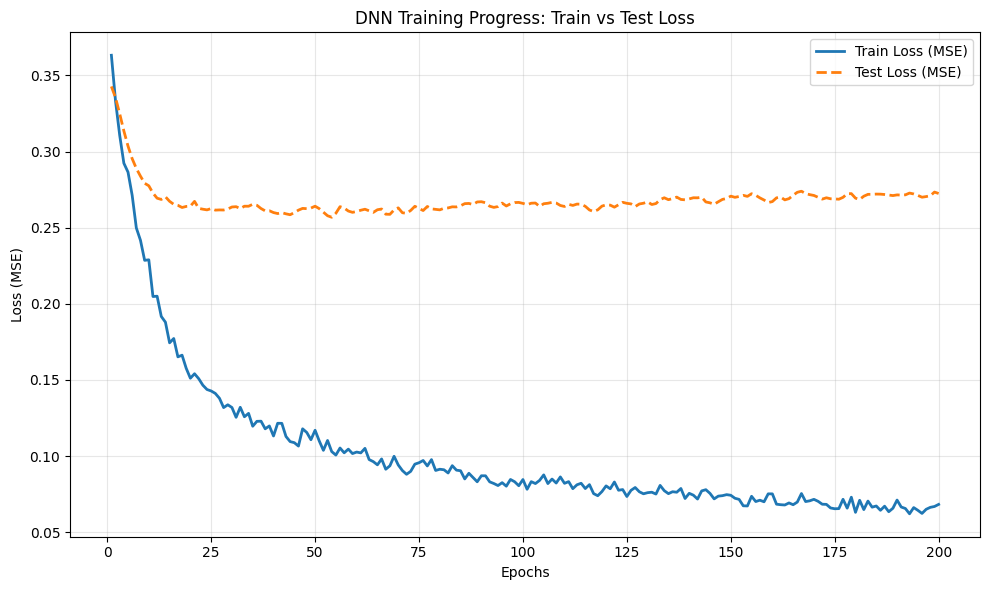


>>> 모든 학습이 완료되었습니다.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. 데이터 로드 및 전처리 설정
# ==========================================
# 파일 경로 설정 (사용자 환경에 맞게 수정 필요)
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'

print(">>> 데이터를 로드하고 전처리를 수행합니다...")

# 데이터 로드
chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')

# 데이터 병합
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# generate_X 함수 정의 (결측치 평균 대치)
def generate_X(X_data, impute=True):
    # 메타데이터 컬럼 제거
    if 'beer_id' in X_data.columns:
        features = X_data.drop(columns=['beer_id'])
    else:
        features = X_data
    
    # 결측치 처리
    if impute:
        features = features.fillna(features.mean())
    return features

# X, Y 데이터 생성
beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# -------------------------------------------------------
# [중요] 이상치 변수 제거 (X2.methyltetrahydrofuran.3.one)
# -------------------------------------------------------
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns:
    X = X.drop(columns=[outlier_col])
    print(f"  -> 이상치 변수 제거 완료: {outlier_col}")

# 데이터 분할 (Stratified Split)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class
)

# 스케일링 (Standard Scaler)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Y값은 범위가 크지 않으므로 스케일링 없이 진행 (필요 시 주석 해제)
# scaler_y = StandardScaler()
# Y_train_scaled = scaler_y.fit_transform(Y_train)
# Y_test_scaled = scaler_y.transform(Y_test)
Y_train_np = Y_train.values
Y_test_np = Y_test.values

print(f"  -> Train shape: {X_train_scaled.shape}")
print(f"  -> Test shape:  {X_test_scaled.shape}")

# ==========================================
# 2. 선형 회귀 모델 (Linear Regression)
# ==========================================
print("\n" + "="*50)
print(">>> [Model 1] Linear Regression 학습 및 평가")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train_np)

# 예측
pred_train_lr = lr_model.predict(X_train_scaled)
pred_test_lr = lr_model.predict(X_test_scaled)

# 평가 지표 계산
r2_tr_lr = r2_score(Y_train_np, pred_train_lr)
rmse_tr_lr = np.sqrt(mean_squared_error(Y_train_np, pred_train_lr))

r2_te_lr = r2_score(Y_test_np, pred_test_lr)
rmse_te_lr = np.sqrt(mean_squared_error(Y_test_np, pred_test_lr))

print(f"  [Train] R^2: {r2_tr_lr:.4f} | RMSE: {rmse_tr_lr:.4f}")
print(f"  [Test]  R^2: {r2_te_lr:.4f} | RMSE: {rmse_te_lr:.4f}")

if r2_tr_lr > 0.9 and r2_te_lr < 0:
    print("  -> 경고: 심각한 과적합(Overfitting)이 의심됩니다.")

# ==========================================
# 3. DNN 모델 (Deep Neural Network)
# ==========================================
print("\n" + "="*50)
print(">>> [Model 2] Deep Neural Network 학습 및 시각화")
print("="*50)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  -> 사용 장치: {device}")

# Tensor 변환
x_tr_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_tr_tensor = torch.FloatTensor(Y_train_np).to(device)
x_te_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_te_tensor = torch.FloatTensor(Y_test_np).to(device)

# DataLoader 설정
train_dataset = TensorDataset(x_tr_tensor, y_tr_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 모델 정의
class BeerDNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BeerDNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
output_dim = Y_train.shape[1]

model = BeerDNN(input_dim, output_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# 학습 Loop
EPOCHS = 200
train_loss_history = []
test_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    # 에폭별 평균 Train Loss
    avg_train_loss = batch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    # Test Loss (Validation)
    model.eval()
    with torch.no_grad():
        test_pred = model(x_te_tensor)
        test_loss = criterion(test_pred, y_te_tensor).item()
        test_loss_history.append(test_loss)
        
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# ==========================================
# 4. 결과 시각화 (Loss Curve)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_loss_history, label='Train Loss (MSE)', linewidth=2)
plt.plot(range(1, EPOCHS + 1), test_loss_history, label='Test Loss (MSE)', linewidth=2, linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('DNN Training Progress: Train vs Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n>>> 모든 학습이 완료되었습니다.")

### 일반화 성능을 높히기 위한 DNN 개선

>>> 데이터 로드 및 전처리 시작...
  -> 이상치 변수 제거: X2.methyltetrahydrofuran.3.one
  -> Train shape: (175, 230)
  -> Test shape:  (75, 230)

>>> [Model 1] ElasticNet (Regularized Linear Regression)
  [Train] R^2: 0.4775 | RMSE: 0.3943
  [Test]  R^2: 0.2046 | RMSE: 0.4978
  -> Best Alpha (Regularization Strength): 0.3478

>>> [Model 2] Robust DNN (Dropout + Weight Decay + Early Stopping)
>>> 학습 시작 (Early Stopping Enabled)...
  Epoch [50/1000] Train Loss: 0.1692 | Test Loss: 0.2593
  Epoch [100/1000] Train Loss: 0.1386 | Test Loss: 0.2591
  -> Early Stopping at Epoch 116. Best Test Loss: 0.2549
------------------------------------------------------------
  [Robust DNN Final Result]
  Best Test Loss (MSE): 0.2549
  Test R^2: 0.1882 | RMSE: 0.5048


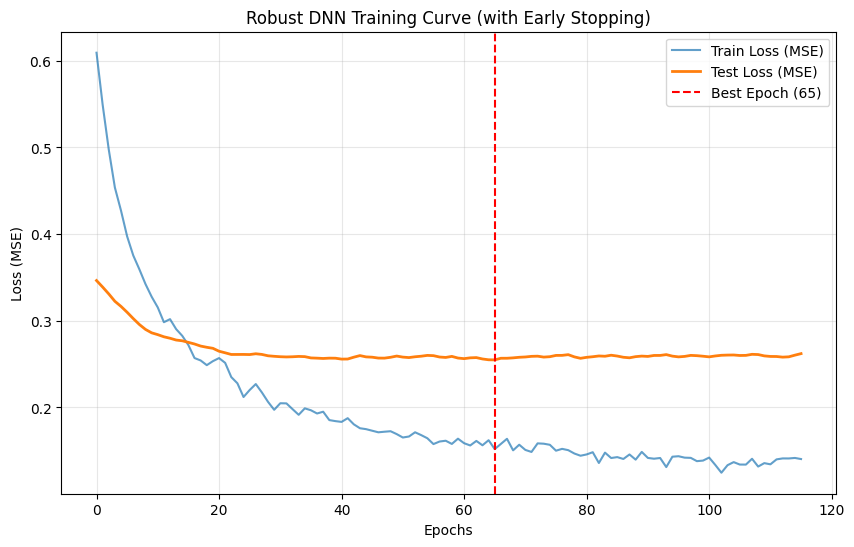

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'

print(">>> 데이터 로드 및 전처리 시작...")

# 데이터 로드
chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')

# 병합
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# 입력 변수(X) 생성 및 결측치 처리
def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns:
        features = X_data.drop(columns=['beer_id'])
    else:
        features = X_data
    if impute:
        features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# [이상치 제거]
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns:
    X = X.drop(columns=[outlier_col])
    print(f"  -> 이상치 변수 제거: {outlier_col}")

# 데이터 분할 (Stratified Split)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class
)

# 스케일링
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

Y_train_np = Y_train.values
Y_test_np = Y_test.values

print(f"  -> Train shape: {X_train_scaled.shape}")
print(f"  -> Test shape:  {X_test_scaled.shape}")

# ==========================================
# 2. 강건한 선형 모델 (ElasticNetCV)
#    : 과적합 방지를 위해 L1+L2 규제가 포함된 모델 사용
# ==========================================
print("\n" + "="*60)
print(">>> [Model 1] ElasticNet (Regularized Linear Regression)")
print("="*60)

# MultiTaskElasticNetCV: 다중 타겟(Y가 여러개)인 경우 사용
# cv=5: 5-Fold 교차검증으로 최적의 alpha(규제 강도) 탐색
from sklearn.linear_model import MultiTaskElasticNetCV

el_model = MultiTaskElasticNetCV(cv=5, random_state=42, n_jobs=-1, max_iter=2000)
el_model.fit(X_train_scaled, Y_train_np)

# 예측
pred_train_el = el_model.predict(X_train_scaled)
pred_test_el = el_model.predict(X_test_scaled)

# 평가
r2_tr = r2_score(Y_train_np, pred_train_el)
rmse_tr = np.sqrt(mean_squared_error(Y_train_np, pred_train_el))

r2_te = r2_score(Y_test_np, pred_test_el)
rmse_te = np.sqrt(mean_squared_error(Y_test_np, pred_test_el))

print(f"  [Train] R^2: {r2_tr:.4f} | RMSE: {rmse_tr:.4f}")
print(f"  [Test]  R^2: {r2_te:.4f} | RMSE: {rmse_te:.4f}")
print(f"  -> Best Alpha (Regularization Strength): {el_model.alpha_:.4f}")

# ==========================================
# 3. 강건한 DNN 모델 (Regularization + Early Stopping)
# ==========================================
print("\n" + "="*60)
print(">>> [Model 2] Robust DNN (Dropout + Weight Decay + Early Stopping)")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tensor 변환
x_tr_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_tr_tensor = torch.FloatTensor(Y_train_np).to(device)
x_te_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_te_tensor = torch.FloatTensor(Y_test_np).to(device)

train_loader = DataLoader(TensorDataset(x_tr_tensor, y_tr_tensor), batch_size=32, shuffle=True)

# 모델 정의 (과적합 방지 구조 적용)
class RobustDNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustDNN, self).__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),        # 학습 안정화
            nn.ReLU(),
            nn.Dropout(0.5),            # 과적합 방지 (50% Drop)
            
            # Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),            # 과적합 방지
            
            # Output Layer
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

model = RobustDNN(X_train_scaled.shape[1], Y_train.shape[1]).to(device)
criterion = nn.MSELoss()

# Optimizer에 Weight Decay(L2 규제) 추가
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 학습 설정
EPOCHS = 1000
patience = 50       # 50 에폭 동안 성능 향상 없으면 조기 종료
best_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

train_losses = []
test_losses = []

print(">>> 학습 시작 (Early Stopping Enabled)...")

for epoch in range(EPOCHS):
    # 1. Train
    model.train()
    batch_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 2. Validation (Test)
    model.eval()
    with torch.no_grad():
        test_pred = model(x_te_tensor)
        test_loss = criterion(test_pred, y_te_tensor).item()
        test_losses.append(test_loss)
    
    # 3. Early Stopping Check
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_wts = copy.deepcopy(model.state_dict()) # 최고 성능 모델 저장
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= patience:
        print(f"  -> Early Stopping at Epoch {epoch+1}. Best Test Loss: {best_loss:.4f}")
        break
        
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# 최적 모델 복원
model.load_state_dict(best_model_wts)

# 최종 평가
model.eval()
with torch.no_grad():
    final_pred = model(x_te_tensor).cpu().numpy()
    final_r2 = r2_score(Y_test_np, final_pred)
    final_rmse = np.sqrt(mean_squared_error(Y_test_np, final_pred))

print("-" * 60)
print(f"  [Robust DNN Final Result]")
print(f"  Best Test Loss (MSE): {best_loss:.4f}")
print(f"  Test R^2: {final_r2:.4f} | RMSE: {final_rmse:.4f}")

# ==========================================
# 4. 결과 시각화 (Loss Curve)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)', alpha=0.7)
plt.plot(test_losses, label='Test Loss (MSE)', linewidth=2)

# Best Epoch 표시
best_epoch = len(train_losses) - early_stop_counter - 1
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')

plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Robust DNN Training Curve (with Early Stopping)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

>>> 데이터 로드 및 전처리...
>>> SAM Optimization 시작 (Device: cpu)
Epoch [50/500] Train Loss: 0.1344 | Test Loss: 0.2587
Early Stopping at Epoch 80
--------------------------------------------------
[SAM DNN Result]
Best Test Loss: 0.2571
Test R^2: 0.1848 | RMSE: 0.5070


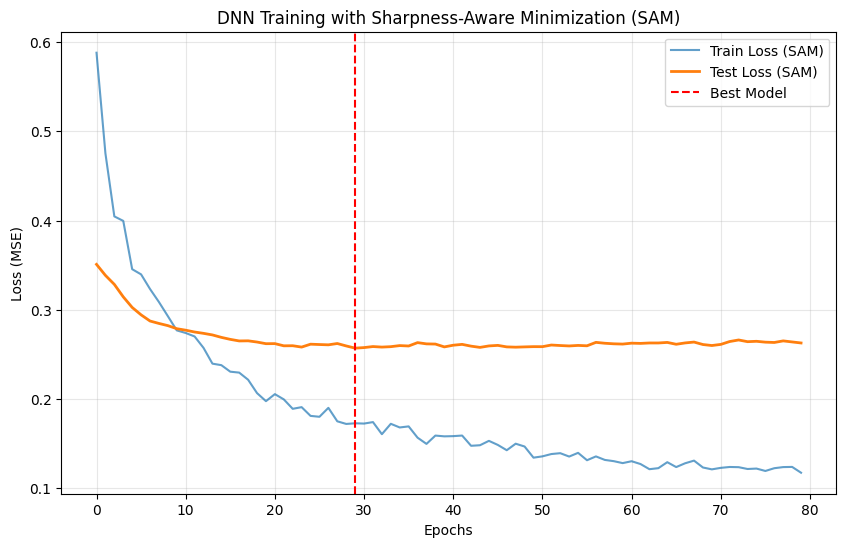

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

# ==========================================
# 1. SAM Optimizer 정의
# ==========================================
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f"Invalid rho, should be non-negative: {rho}"

        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)

        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)

            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)  # Climb to the local maximum "w + e(w)"

        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]  # Get back to "w" from "w + e(w)"

        self.base_optimizer.step()  # Do the actual "sharpness-aware" update

        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device  # put everything on the same device
        norm = torch.norm(
                    torch.stack([
                        ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
                        for group in self.param_groups for p in group["params"]
                        if p.grad is not None
                    ]),
                    p=2
               )
        return norm
    
    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none)

# ==========================================
# 2. 데이터 준비 (이전과 동일)
# ==========================================
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'
print(">>> 데이터 로드 및 전처리...")

chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns: features = X_data.drop(columns=['beer_id'])
    else: features = X_data
    if impute: features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# 이상치 제거
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns: X = X.drop(columns=[outlier_col])

# 분할 및 스케일링
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class)

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_tr_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_tr_tensor = torch.FloatTensor(Y_train.values).to(device)
x_te_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_te_tensor = torch.FloatTensor(Y_test.values).to(device)

train_loader = DataLoader(TensorDataset(x_tr_tensor, y_tr_tensor), batch_size=32, shuffle=True)

# ==========================================
# 3. DNN 모델 정의
# ==========================================
class RobustDNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustDNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),  # Dropout 유지
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

model = RobustDNN(X_train_scaled.shape[1], Y_train.shape[1]).to(device)
criterion = nn.MSELoss()

# ★ SAM Optimizer 적용 (Base Optimizer: AdamW)
# rho: 이웃을 탐색할 반경 (보통 0.05 ~ 0.2 사용)
base_optimizer = torch.optim.AdamW
optimizer = SAM(model.parameters(), base_optimizer, rho=0.05, lr=0.001, weight_decay=1e-4)

# ==========================================
# 4. SAM 학습 Loop
# ==========================================
EPOCHS = 500  # SAM은 수렴이 더 빠르고 안정적이므로 에폭을 적절히 조절
train_losses = []
test_losses = []
best_loss = float('inf')
patience = 50
counter = 0

print(f">>> SAM Optimization 시작 (Device: {device})")

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0
    
    for x_batch, y_batch in train_loader:
        # [Step 1] 첫 번째 Forward-Backward (Loss 구하기)
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        
        # [Step 2] 가중치를 Loss가 커지는 방향(Ascent)으로 살짝 이동
        optimizer.first_step(zero_grad=True)
        
        # [Step 3] 두 번째 Forward-Backward (이동한 위치에서 기울기 구하기)
        criterion(model(x_batch), y_batch).backward()
        
        # [Step 4] 원래 위치로 돌아와서 실제 업데이트 (Descent)
        optimizer.second_step(zero_grad=True)
        
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        test_pred = model(x_te_tensor)
        test_loss = criterion(test_pred, y_te_tensor).item()
        test_losses.append(test_loss)
        
    # Early Stopping
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early Stopping at Epoch {epoch+1}")
            break
            
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# 최적 모델 로드 및 평가
model.load_state_dict(best_model_wts)
model.eval()
with torch.no_grad():
    final_pred = model(x_te_tensor).cpu().numpy()
    final_r2 = r2_score(Y_test.values, final_pred)
    final_rmse = np.sqrt(mean_squared_error(Y_test.values, final_pred))

print("-" * 50)
print(f"[SAM DNN Result]")
print(f"Best Test Loss: {best_loss:.4f}")
print(f"Test R^2: {final_r2:.4f} | RMSE: {final_rmse:.4f}")

# ==========================================
# 5. 결과 시각화
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (SAM)', alpha=0.7)
plt.plot(test_losses, label='Test Loss (SAM)', linewidth=2)
plt.axvline(x=len(train_losses)-counter-1, color='r', linestyle='--', label='Best Model')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('DNN Training with Sharpness-Aware Minimization (SAM)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

>>> 데이터 로드 및 전처리...
>>> 초거대 모델 학습 시작 (Epochs: 3000)...
  Epoch [500/3000] Train Loss: 0.01998 | Test Loss: 0.26987
  Epoch [1000/3000] Train Loss: 0.01347 | Test Loss: 0.26660
  Epoch [1500/3000] Train Loss: 0.01251 | Test Loss: 0.26611
  Epoch [2000/3000] Train Loss: 0.00984 | Test Loss: 0.26561
  Epoch [2500/3000] Train Loss: 0.00970 | Test Loss: 0.26462
  Epoch [3000/3000] Train Loss: 0.00842 | Test Loss: 0.26417
--------------------------------------------------
[Over-parameterized Model Result]
Test R^2: 0.1435 | RMSE: 0.5140


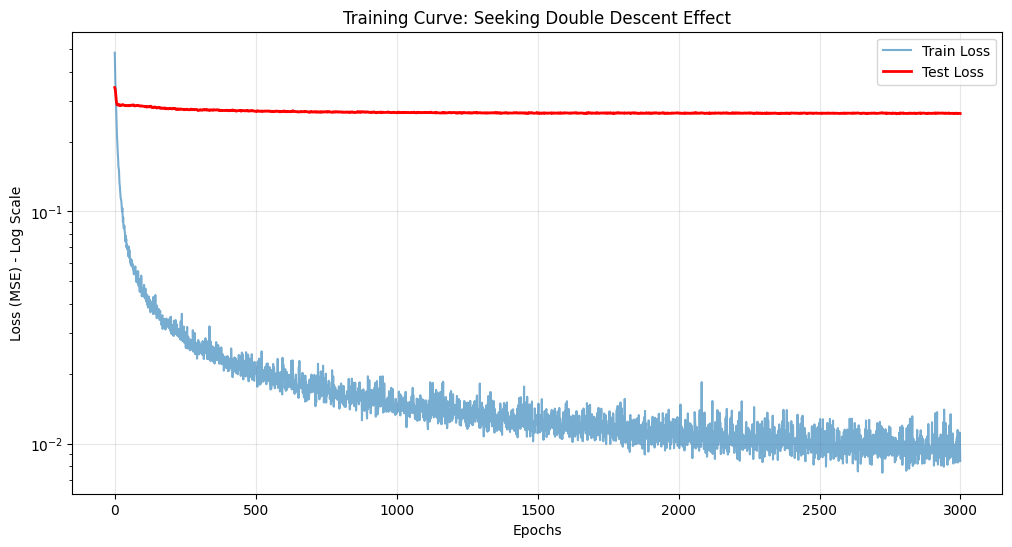

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. 데이터 준비 (이전과 동일)
# ==========================================
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'
print(">>> 데이터 로드 및 전처리...")

chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns: features = X_data.drop(columns=['beer_id'])
    else: features = X_data
    if impute: features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# 이상치 제거
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns: X = X.drop(columns=[outlier_col])

# 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class)

# 스케일링
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_tr_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_tr_tensor = torch.FloatTensor(Y_train.values).to(device)
x_te_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_te_tensor = torch.FloatTensor(Y_test.values).to(device)

train_loader = DataLoader(TensorDataset(x_tr_tensor, y_tr_tensor), batch_size=64, shuffle=True)

# ==========================================
# 2. Over-parameterized Model 설계
# ==========================================
# Double Descent를 위해 데이터 수(N)보다 훨씬 큰 파라미터(P)를 갖도록 설계
# N ~ 200, but Hidden Nodes = 2048 (Parameters > 1 Million)
class OverParameterizedDNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(OverParameterizedDNN, self).__init__()
        self.net = nn.Sequential(
            # 엄청나게 넓은 은닉층 (Wide Layer)
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            # Dropout을 쓰지 않거나 낮게 설정하여 과적합 구간을 통과하도록 유도하기도 함
            # 여기서는 일반화 성능을 위해 약간만 적용
            nn.Dropout(0.2), 
            
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Linear(1024, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
output_dim = Y_train.shape[1]

model = OverParameterizedDNN(input_dim, output_dim).to(device)
criterion = nn.MSELoss()
# SGD가 Double Descent를 관찰하기에 더 적합하다는 연구가 많음 (Implicit Regularization)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
# 또는 AdamW 사용 가능
# optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================
# 3. 장기 학습 (Long Training)
# ==========================================
# Interpolation Threshold(Train Loss ~ 0)를 지나서도 계속 학습해야 함
EPOCHS = 3000  
train_losses = []
test_losses = []

print(f">>> 초거대 모델 학습 시작 (Epochs: {EPOCHS})...")

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        test_pred = model(x_te_tensor)
        test_loss = criterion(test_pred, y_te_tensor).item()
        test_losses.append(test_loss)
        
    if (epoch+1) % 500 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.5f} | Test Loss: {test_loss:.5f}")

# 최종 평가
model.eval()
with torch.no_grad():
    final_pred = model(x_te_tensor).cpu().numpy()
    final_r2 = r2_score(Y_test.values, final_pred)
    final_rmse = np.sqrt(mean_squared_error(Y_test.values, final_pred))

print("-" * 50)
print(f"[Over-parameterized Model Result]")
print(f"Test R^2: {final_r2:.4f} | RMSE: {final_rmse:.4f}")

# ==========================================
# 4. 결과 시각화 (Epoch-wise Double Descent 확인)
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss', alpha=0.6)
plt.plot(test_losses, label='Test Loss', linewidth=2, color='red')

# 로그 스케일로 보면 초기 급격한 변화와 후반부 미세 조정을 보기 좋음
plt.yscale('log') 
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE) - Log Scale')
plt.title('Training Curve: Seeking Double Descent Effect')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- 일반화 성능을 올리려면 데이터 수가 더 필요할 수 있음.
- 이를 생성모델을 사용하여 분포를 정확히 추정하여 더 나아가 원하는 데이터를 생성할 수 있음

>>> 데이터 로드 및 전처리...
  -> Total Input Dimension: 280

>>> Deep Residual AE 학습 시작 (Capacity Increased, L1 Loss)...
  Epoch [50/500] Train L1: 0.27131 | Test L1: 0.48508
  Epoch [100/500] Train L1: 0.19874 | Test L1: 0.47861
  Epoch [150/500] Train L1: 0.16579 | Test L1: 0.47360
  Epoch [200/500] Train L1: 0.15224 | Test L1: 0.47487
  Epoch [250/500] Train L1: 0.13711 | Test L1: 0.47462
  Epoch [300/500] Train L1: 0.11364 | Test L1: 0.47046
  Epoch [350/500] Train L1: 0.11862 | Test L1: 0.46784
  Epoch [400/500] Train L1: 0.10227 | Test L1: 0.46949
  Epoch [450/500] Train L1: 0.11138 | Test L1: 0.47455
  Epoch [500/500] Train L1: 0.10059 | Test L1: 0.47055


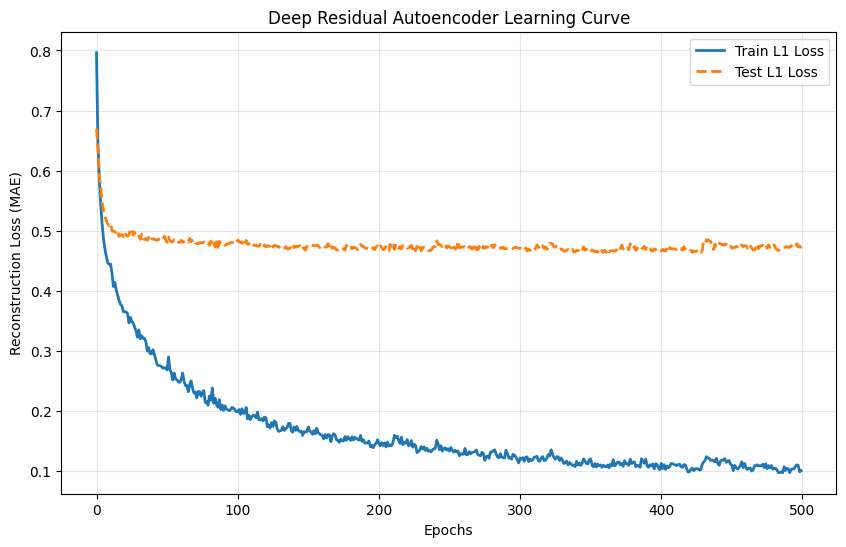


>>> 학습 및 시각화 완료.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. 데이터 준비 (Data Preparation)
# ==========================================
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'
print(">>> 데이터 로드 및 전처리...")

# 로드
chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# X 생성
def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns:
        features = X_data.drop(columns=['beer_id'])
    else:
        features = X_data
    if impute:
        features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# [이상치 제거] 231 -> 230개
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns:
    X = X.drop(columns=[outlier_col])

# 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class
)

# 스케일링
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
Y_train_scaled = scaler_y.fit_transform(Y_train)
Y_test_scaled = scaler_y.transform(Y_test)

# 데이터 결합 (X + Y) -> 280차원
train_data = np.concatenate([X_train_scaled, Y_train_scaled], axis=1)
test_data = np.concatenate([X_test_scaled, Y_test_scaled], axis=1)

input_dim = train_data.shape[1] # 230 + 50 = 280
print(f"  -> Total Input Dimension: {input_dim}")

# Tensor 변환
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_tensor = torch.FloatTensor(train_data).to(device)
test_tensor = torch.FloatTensor(test_data).to(device)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)

# ==========================================
# 2. Residual Block 정의 (Skip Connection)
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(ResBlock, self).__init__()
        
        # Main Path
        self.main_path = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )
        
        # Skip Connection (Projection if dim mismatch)
        if in_dim != out_dim:
            self.shortcut = nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim)
            )
        else:
            self.shortcut = nn.Identity()
            
        self.final_act = nn.LeakyReLU(0.2)

    def forward(self, x):
        # F(x) + x 구조 (Residual Learning)
        residual = self.shortcut(x)
        out = self.main_path(x)
        return self.final_act(out + residual)

# ==========================================
# 3. Deep Residual Autoencoder (High Capacity)
# ==========================================
class DeepResAE(nn.Module):
    def __init__(self, input_dim):
        super(DeepResAE, self).__init__()
        
        # --- Encoder (Residual) ---
        # 280 -> 1024 -> 512 -> 256 -> 128 (Latent)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),      # Expand First
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            
            ResBlock(1024, 1024),            # Deep Processing
            ResBlock(1024, 512),             # Downsample
            ResBlock(512, 256),              # Downsample
            
            nn.Linear(256, 128)              # Bottleneck (No BN/Act for pure latent)
        )
        
        # --- Decoder (Residual) ---
        # 128 -> 256 -> 512 -> 1024 -> 280
        # Encoder와 Decoder 사이의 Skip Connection은 없음 (Standard AE)
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),             # Expand Latent
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            ResBlock(256, 512),              # Upsample
            ResBlock(512, 1024),             # Upsample
            ResBlock(1024, 1024),            # Deep Processing
            
            nn.Linear(1024, input_dim)       # Reconstruction
        )
        
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

model = DeepResAE(input_dim).to(device)

# L1 Loss 설정
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Large model -> Lower LR recommended

# ==========================================
# 4. 학습 및 시각화
# ==========================================
EPOCHS = 500
train_losses = []
test_losses = []

print(f"\n>>> Deep Residual AE 학습 시작 (Capacity Increased, L1 Loss)...")

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0
    for (x_batch,) in train_loader:
        optimizer.zero_grad()
        recon = model(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        test_recon = model(test_tensor)
        test_loss = criterion(test_recon, test_tensor).item()
        test_losses.append(test_loss)
        
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}] Train L1: {avg_train_loss:.5f} | Test L1: {test_loss:.5f}")

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train L1 Loss', linewidth=2)
plt.plot(test_losses, label='Test L1 Loss', linewidth=2, linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Reconstruction Loss (MAE)')
plt.title('Deep Residual Autoencoder Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n>>> 학습 및 시각화 완료.")

>>> 데이터 로드 및 전처리...
  -> Total Input Dimension: 280

>>> 초대형 Autoencoder 학습 시작 (10,000 Epochs)...
  Epoch [500/10000] Train L1: 0.083824 | Test L1: 0.514500 | LR: 0.001000
  Epoch [1000/10000] Train L1: 0.057110 | Test L1: 0.500453 | LR: 0.000500
  Epoch [1500/10000] Train L1: 0.035754 | Test L1: 0.508484 | LR: 0.000250
  Epoch [2000/10000] Train L1: 0.028453 | Test L1: 0.507344 | LR: 0.000125
  Epoch [2500/10000] Train L1: 0.025661 | Test L1: 0.512669 | LR: 0.000063
  Epoch [3000/10000] Train L1: 0.022213 | Test L1: 0.514315 | LR: 0.000031
  Epoch [3500/10000] Train L1: 0.022460 | Test L1: 0.508120 | LR: 0.000016
  Epoch [4000/10000] Train L1: 0.019309 | Test L1: 0.506823 | LR: 0.000008
  Epoch [4500/10000] Train L1: 0.021761 | Test L1: 0.509243 | LR: 0.000004
  Epoch [5000/10000] Train L1: 0.020972 | Test L1: 0.511997 | LR: 0.000002
  Epoch [5500/10000] Train L1: 0.018875 | Test L1: 0.509090 | LR: 0.000001
  Epoch [6000/10000] Train L1: 0.020861 | Test L1: 0.518433 | LR: 0.000000
  E

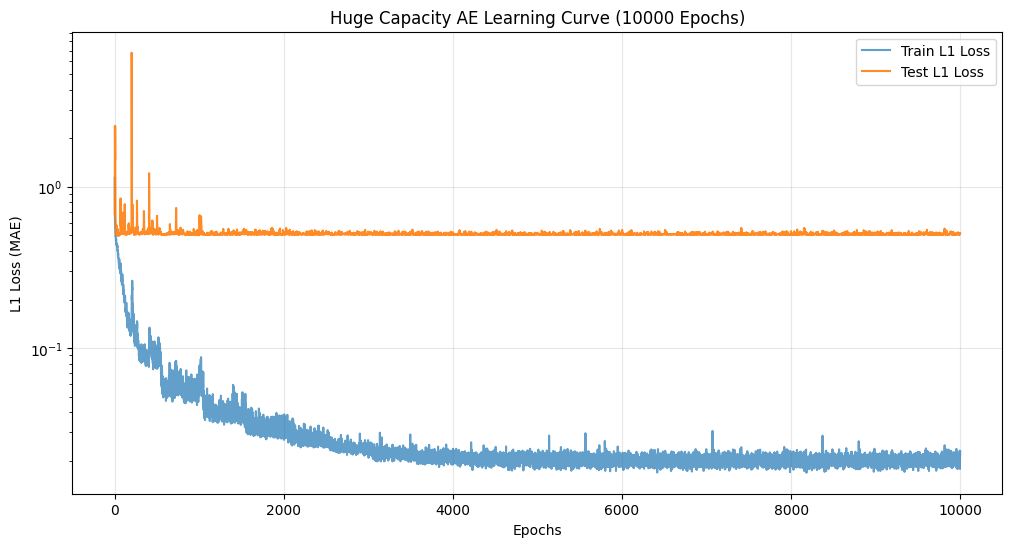


>>> 10,000 Epoch 학습 완료.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. 데이터 준비 (Data Preparation)
# ==========================================
EXCEL_PATH = 'Supplemental Files and Figure source files.xlsx'
print(">>> 데이터 로드 및 전처리...")

# 데이터 로드
chem_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S1').set_index('beer')
trained_panel_dataset = pd.read_excel(EXCEL_PATH, sheet_name='Supplementary File S4').set_index('beer')
chem_dataset_expertpanel = chem_dataset.join(trained_panel_dataset, lsuffix='_chem', rsuffix='_panel')

# X 생성 함수
def generate_X(X_data, impute=True):
    if 'beer_id' in X_data.columns:
        features = X_data.drop(columns=['beer_id'])
    else:
        features = X_data
    if impute:
        features = features.fillna(features.mean())
    return features

beer_id_col = chem_dataset_expertpanel['beer_id_chem'].rename('beer_id')
target_features = chem_dataset_expertpanel.loc[:, 'acetaldehyde':'sulfur_sum']
X_input = pd.concat([beer_id_col, target_features], axis=1)

X = generate_X(X_input, impute=True)
Y = chem_dataset_expertpanel.loc[:, 'A_malt_all':'overall']
y_class = chem_dataset_expertpanel.loc[:, 'tasting_category_fine_chem']

# [이상치 제거]
outlier_col = 'X2.methyltetrahydrofuran.3.one'
if outlier_col in X.columns:
    X = X.drop(columns=[outlier_col])

# 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, shuffle=True, stratify=y_class
)

# 스케일링
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
Y_train_scaled = scaler_y.fit_transform(Y_train)
Y_test_scaled = scaler_y.transform(Y_test)

# 데이터 결합 (280차원)
train_data = np.concatenate([X_train_scaled, Y_train_scaled], axis=1)
test_data = np.concatenate([X_test_scaled, Y_test_scaled], axis=1)

input_dim = train_data.shape[1]
print(f"  -> Total Input Dimension: {input_dim}")

# Tensor 변환
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_tensor = torch.FloatTensor(train_data).to(device)
test_tensor = torch.FloatTensor(test_data).to(device)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

# ==========================================
# 2. 초대형 모델 설계 (Huge Capacity)
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(ResBlock, self).__init__()
        self.main_path = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),    # Batch Norm
            nn.LeakyReLU(0.2),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim)     # Batch Norm
        )
        if in_dim != out_dim:
            self.shortcut = nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim)
            )
        else:
            self.shortcut = nn.Identity()
            
        self.final_act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.final_act(self.main_path(x) + self.shortcut(x))

class HugeResAE(nn.Module):
    def __init__(self, input_dim):
        super(HugeResAE, self).__init__()
        
        # --- Encoder (Very Deep & Wide) ---
        # 280 -> 2048 -> 1024 -> 512 -> 256 -> 128
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.2),
            
            # Deep Residual Processing
            ResBlock(2048, 2048),
            ResBlock(2048, 2048),
            
            ResBlock(2048, 1024), # Downsample
            ResBlock(1024, 1024),
            
            ResBlock(1024, 512),  # Downsample
            ResBlock(512, 512),
            
            ResBlock(512, 256),   # Downsample
            
            nn.Linear(256, 128)   # Bottleneck
        )
        
        # --- Decoder (Mirror of Encoder) ---
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            ResBlock(256, 512),   # Upsample
            ResBlock(512, 512),
            
            ResBlock(512, 1024),  # Upsample
            ResBlock(1024, 1024),
            
            ResBlock(1024, 2048), # Upsample
            ResBlock(2048, 2048),
            ResBlock(2048, 2048),
            
            nn.Linear(2048, input_dim) # Reconstruction
        )
        
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

model = HugeResAE(input_dim).to(device)

# L1 Loss & Optimizer
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning Rate Scheduler (Loss가 정체되면 LR 감소)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=500, verbose=True
)

# ==========================================
# 3. 장기 학습 (Long Training)
# ==========================================
EPOCHS = 10000
train_losses = []
test_losses = []

print(f"\n>>> 초대형 Autoencoder 학습 시작 (10,000 Epochs)...")

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0
    for (x_batch,) in train_loader:
        optimizer.zero_grad()
        recon = model(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        test_recon = model(test_tensor)
        test_loss = criterion(test_recon, test_tensor).item()
        test_losses.append(test_loss)
    
    # Scheduler Step
    scheduler.step(test_loss)
        
    if (epoch + 1) % 500 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}] Train L1: {avg_train_loss:.6f} | Test L1: {test_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ==========================================
# 4. 결과 시각화 (Log Scale)
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train L1 Loss', alpha=0.7)
plt.plot(test_losses, label='Test L1 Loss', linewidth=1.5, alpha=0.9)
plt.xlabel('Epochs')
plt.ylabel('L1 Loss (MAE)')
plt.title(f'Huge Capacity AE Learning Curve ({EPOCHS} Epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # 변화폭을 보기 위해 로그 스케일 적용
plt.show()

print("\n>>> 10,000 Epoch 학습 완료.")